<a href="https://colab.research.google.com/github/gagan3754/Business-Case-OLA---Ensemble-Learning/blob/main/Business_Case_OLA_Ensemble_Learning_polished_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem Statement

Recruiting and retaining drivers is seen by industry watchers as a tough battle for Ola. Churn among drivers is high and it’s very easy for drivers to stop working for the service on the fly or jump to Uber depending on the rates.

As the companies get bigger, the high churn could become a bigger problem. To find new drivers, Ola is casting a wide net, including people who don’t have cars for jobs. But this acquisition is really costly. Losing drivers frequently impacts the morale of the organization and acquiring new drivers is more expensive than retaining existing ones.

You are working as a data scientist with the Analytics Department of Ola, focused on driver team attrition. You are provided with the monthly information for a segment of drivers for 2019 and 2020 and tasked to predict whether a driver will be leaving the company or not based on their attributes like

Demographics (city, age, gender etc.)
Tenure information (joining date, Last Date)
Historical data regarding the performance of the driver (Quarterly rating, Monthly business acquired, grade, Income)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
!wget 'https://drive.google.com/uc?export=download&id=1EiteSffXaI3rvFmqn411cDpdLo2pBHZc' -O ola.csv

--2025-12-01 02:12:37--  https://drive.google.com/uc?export=download&id=1EiteSffXaI3rvFmqn411cDpdLo2pBHZc
Resolving drive.google.com (drive.google.com)... 173.194.217.101, 173.194.217.138, 173.194.217.113, ...
Connecting to drive.google.com (drive.google.com)|173.194.217.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1EiteSffXaI3rvFmqn411cDpdLo2pBHZc&export=download [following]
--2025-12-01 02:12:37--  https://drive.usercontent.google.com/download?id=1EiteSffXaI3rvFmqn411cDpdLo2pBHZc&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.210.132, 2607:f8b0:400c:c0f::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.210.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1127673 (1.1M) [application/octet-stream]
Saving to: ‘ola.csv’

ola.csv             100%[===================>]   1.08M  --.-KB/s 

In [ ]:
df=pd.read_csv("ola.csv")

In [ ]:
df.head()

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [ ]:
#shape of dataframe
df.shape

(19104, 14)

Rows - 14

columns - 19104

In [ ]:
df.columns

Index(['Unnamed: 0', 'MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City',
       'Education_Level', 'Income', 'Dateofjoining', 'LastWorkingDate',
       'Joining Designation', 'Grade', 'Total Business Value',
       'Quarterly Rating'],
      dtype='object')

In [ ]:
# datatypes of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+ MB


Column Unnamed: 0 is number from 1 to 19104 so it does'nt give any meaningful information or has impact on the target variable

In [ ]:
df.drop(columns='Unnamed: 0',inplace=True)

In [ ]:
df.head()

,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


Convert the the columns MMM-YY , Dateofjoining and LastWorkingDate to time format

In [ ]:
df['MMM-YY']=pd.to_datetime(df['MMM-YY'])
df['LastWorkingDate']=pd.to_datetime(df['LastWorkingDate'])
df['Dateofjoining']=pd.to_datetime(df['Dateofjoining'])

convert column city to category as it is not unique and is repeating

In [ ]:
df['City']=df['City'].astype('category')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   MMM-YY                19104 non-null  datetime64[ns]
 1   Driver_ID             19104 non-null  int64         
 2   Age                   19043 non-null  float64       
 3   Gender                19052 non-null  float64       
 4   City                  19104 non-null  category      
 5   Education_Level       19104 non-null  int64         
 6   Income                19104 non-null  int64         
 7   Dateofjoining         19104 non-null  datetime64[ns]
 8   LastWorkingDate       1616 non-null   datetime64[ns]
 9   Joining Designation   19104 non-null  int64         
 10  Grade                 19104 non-null  int64         
 11  Total Business Value  19104 non-null  int64         
 12  Quarterly Rating      19104 non-null  int64         
dtypes: category(1), 

No of unique values for each column

In [ ]:
for i in df.columns:
  print(i,":",df[i].nunique())
  print("-"*50)

MMM-YY : 24
--------------------------------------------------
Driver_ID : 2381
--------------------------------------------------
Age : 36
--------------------------------------------------
Gender : 2
--------------------------------------------------
City : 29
--------------------------------------------------
Education_Level : 3
--------------------------------------------------
Income : 2383
--------------------------------------------------
Dateofjoining : 869
--------------------------------------------------
LastWorkingDate : 493
--------------------------------------------------
Joining Designation : 5
--------------------------------------------------
Grade : 5
--------------------------------------------------
Total Business Value : 10181
--------------------------------------------------
Quarterly Rating : 4
--------------------------------------------------


Find the missing value in dataframe

In [ ]:
# Missing value
df.isnull().sum()

,0
MMM-YY,0
Driver_ID,0
Age,61
Gender,52
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,17488
Joining Designation,0


Statistical summary

In [ ]:
df.describe()

,MMM-YY,Driver_ID,Age,Gender,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
count,19104,19104.000000,19043.000000,19052.000000,19104.000000,19104.000000,19104,1616,19104.000000,19104.000000,1.910400e+04,19104.000000
mean,2019-12-11 02:09:29.849246464,1415.591133,34.668435,0.418749,1.021671,65652.025126,2018-04-28 20:52:54.874371840,2019-12-21 20:59:06.534653696,1.690536,2.252670,5.716621e+05,2.008899
min,2019-01-01 00:00:00,1.000000,21.000000,0.000000,0.000000,10747.000000,2013-04-01 00:00:00,2018-12-31 00:00:00,1.000000,1.000000,-6.000000e+06,1.000000
25%,2019-06-01 00:00:00,710.000000,30.000000,0.000000,0.000000,42383.000000,2016-11-29 12:00:00,2019-06-06 00:00:00,1.000000,1.000000,0.000000e+00,1.000000
50%,2019-12-01 00:00:00,1417.000000,34.000000,0.000000,1.000000,60087.000000,2018-09-12 00:00:00,2019-12-20 12:00:00,1.000000,2.000000,2.500000e+05,2.000000
75%,2020-07-01 00:00:00,2137.000000,39.000000,1.000000,2.000000,83969.000000,2019-11-05 00:00:00,2020-07-03 00:00:00,2.000000,3.000000,6.997000e+05,3.000000
max,2020-12-01 00:00:00,2788.000000,58.000000,1.000000,2.000000,188418.000000,2020-12-28 00:00:00,2020-12-28 00:00:00,5.000000,5.000000,3.374772e+07,4.000000
std,NaN,810.705321,6.257912,0.493367,0.800167,30914.515344,NaN,NaN,0.836984,1.026512,1.128312e+06,1.009832


Univariate Analysis

In [ ]:
df.head()

,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,2019-01-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,2381060,2
1,2019-02-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,-665480,2
2,2019-03-01,1,28.0,0.0,C23,2,57387,2018-12-24,2019-03-11,1,1,0,2
3,2020-11-01,2,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0,1
4,2020-12-01,2,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0,1


countplot

In [ ]:
plt.rcParams['figure.figsize']=(16,10)

In [ ]:
col1=['Gender','Education_Level','Joining Designation','Grade','Quarterly Rating']
for col in col1:
  print(col," : ",df[col].value_counts())
  print("-"*50)

Gender  :  Gender
0.0    11074
1.0     7978
Name: count, dtype: int64
--------------------------------------------------
Education_Level  :  Education_Level
1    6864
2    6327
0    5913
Name: count, dtype: int64
--------------------------------------------------
Joining Designation  :  Joining Designation
1    9831
2    5955
3    2847
4     341
5     130
Name: count, dtype: int64
--------------------------------------------------
Grade  :  Grade
2    6627
1    5202
3    4826
4    2144
5     305
Name: count, dtype: int64
--------------------------------------------------
Quarterly Rating  :  Quarterly Rating
1    7679
2    5553
3    3895
4    1977
Name: count, dtype: int64
--------------------------------------------------


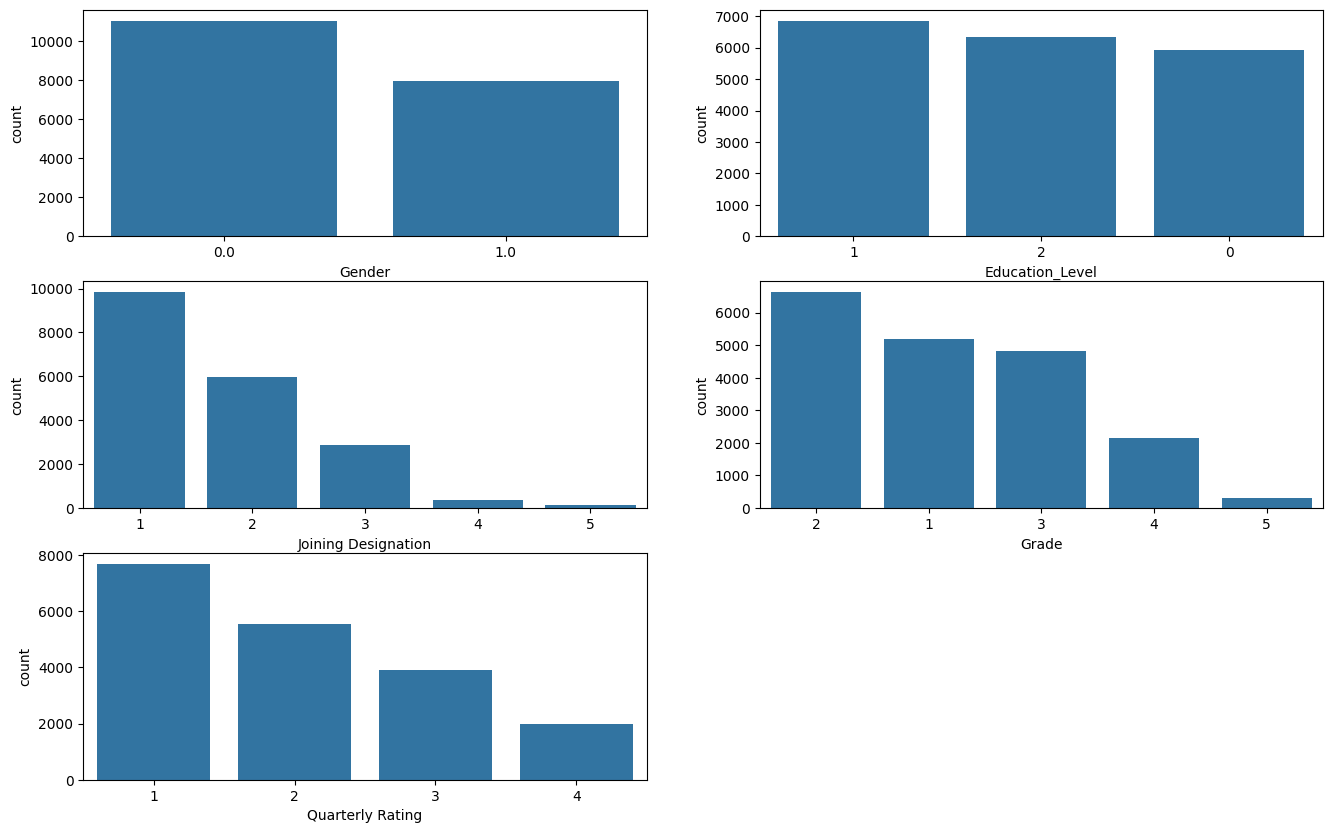

In [ ]:
k=1
for i in col1:
  plt.subplot(3,2,k)
  sns.countplot(data=df,x=i,order=df[i].value_counts().index)
  k+=1

Gender - Male (0) has higher count comapred to female (1)

Education_level - 12+ are higher then followed by graduates and 10+ educates

joining designation - 1 is higher comapred to others and 4,5 being lowest

Grade - 2 is high compared to others

Quarterly Rating - 1 is higher compared to other rating

<Axes: xlabel='City', ylabel='count'>

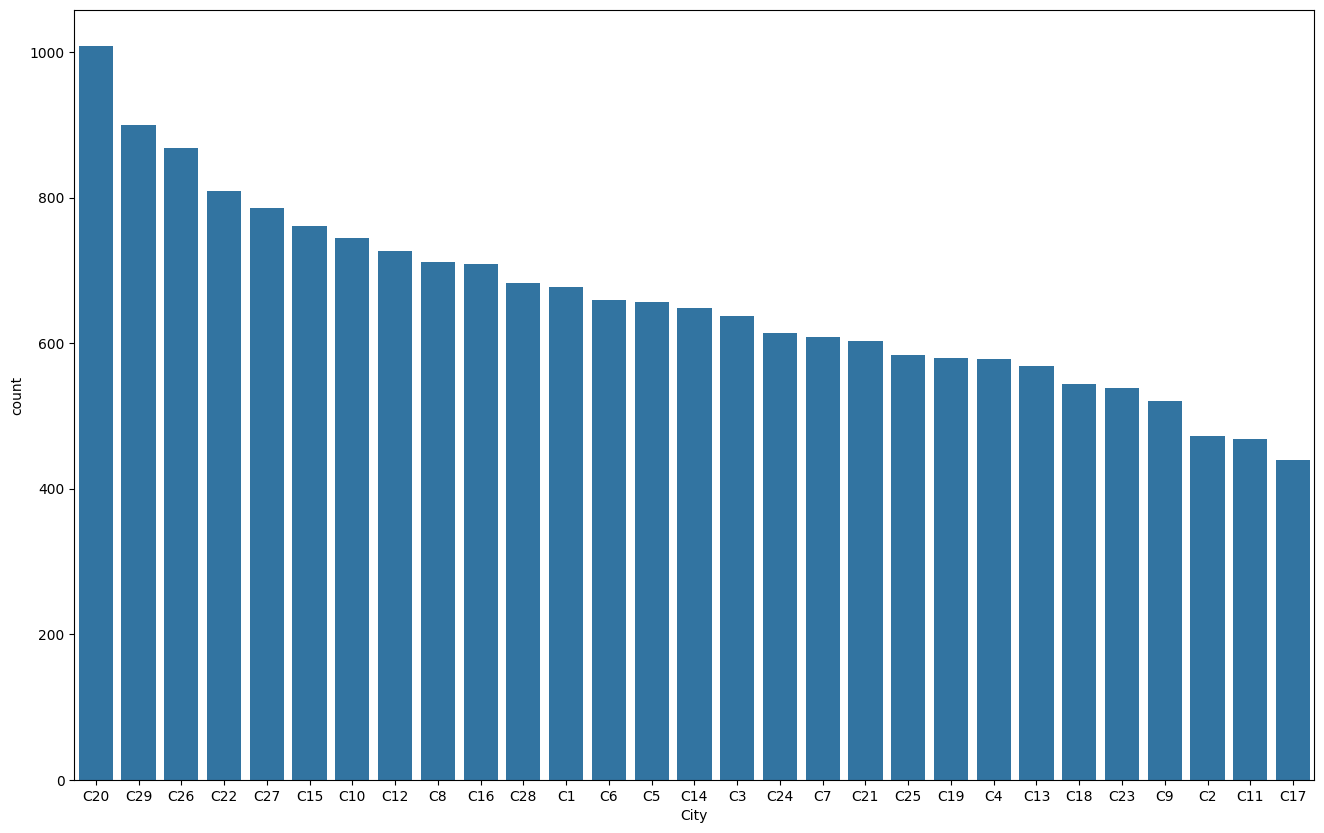

In [ ]:
sns.countplot(data=df,x='City',order=df['City'].value_counts().index)

City - C20 has higher count comapred to other

Histogram

In [ ]:
date1=['MMM-YY','Dateofjoining','LastWorkingDate']

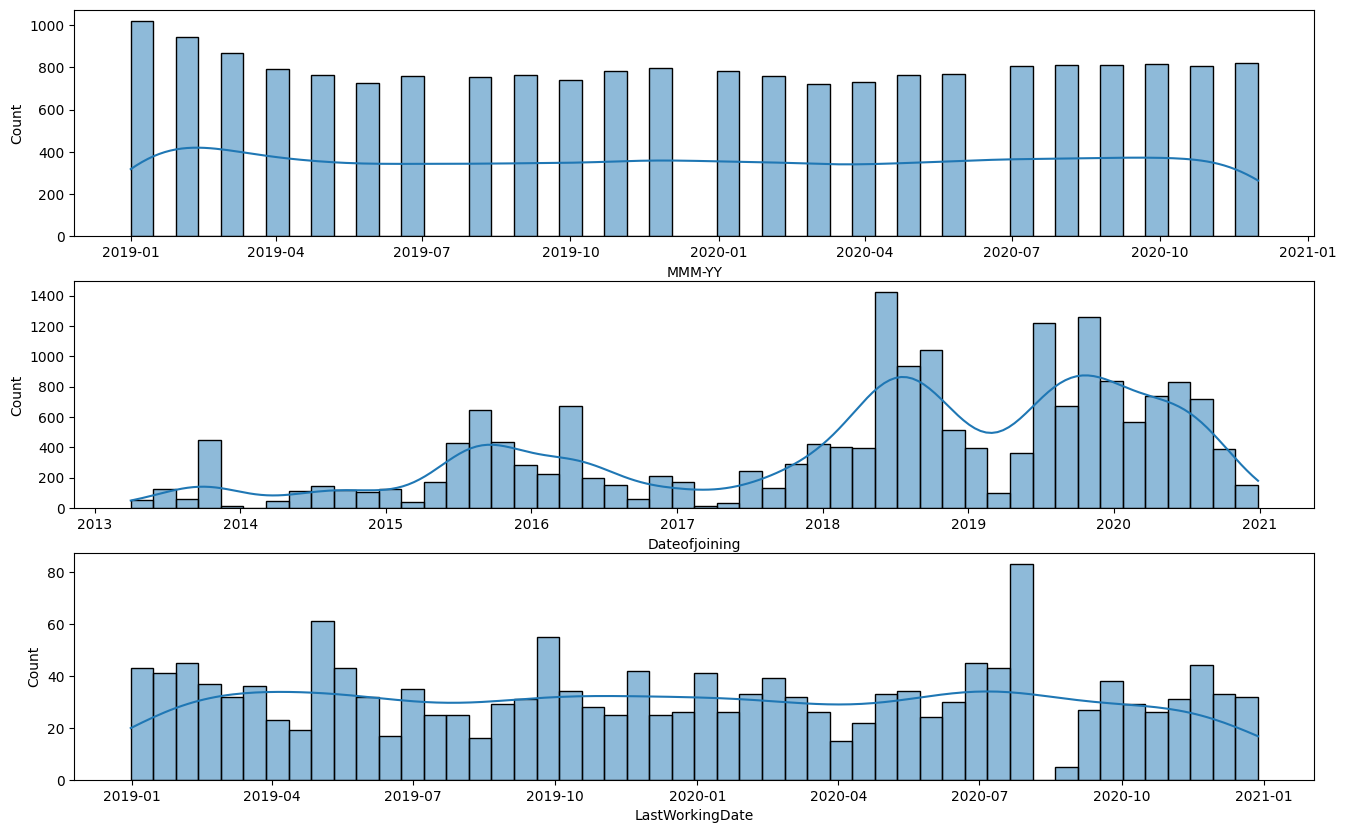

In [ ]:
k=1
for col in date1:
  plt.subplot(3,1,k)
  sns.histplot(df[col],bins=50,kde=True)
  k+=1

MMM-YY,Dateofjoining,LastWorkingDate distribution is not normal

Boxplot

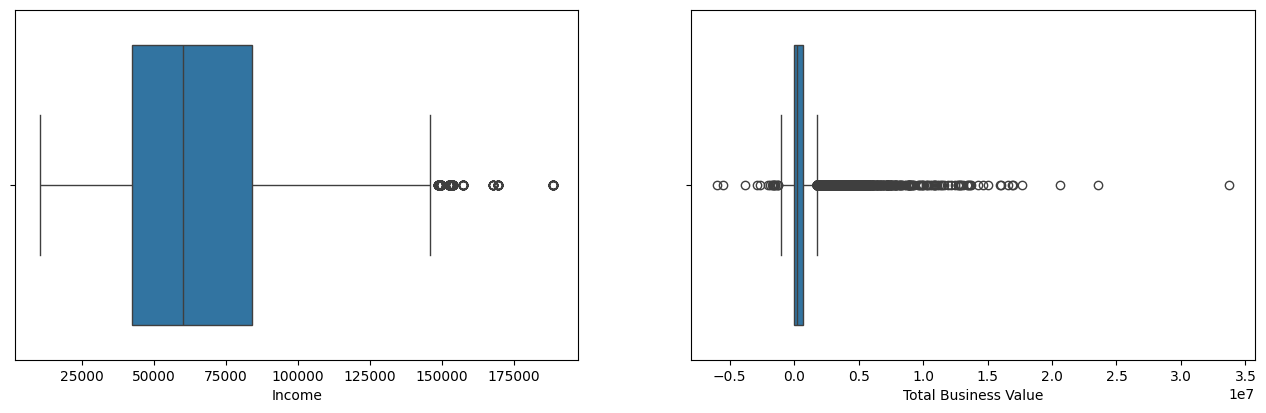

In [ ]:
col2=['Income','Total Business Value']
k=1
for col in col2:
  plt.subplot(2,2,k)
  sns.boxplot(data=df,x=col)
  k+=1

Income and Total Business value have outliers but these are real time value income can be really high for some people , there can be low or high total business value for a person

Bivariate analysis

In [ ]:
col1=['Education_Level',
 'Joining Designation',
 'Grade',
 'Quarterly Rating']

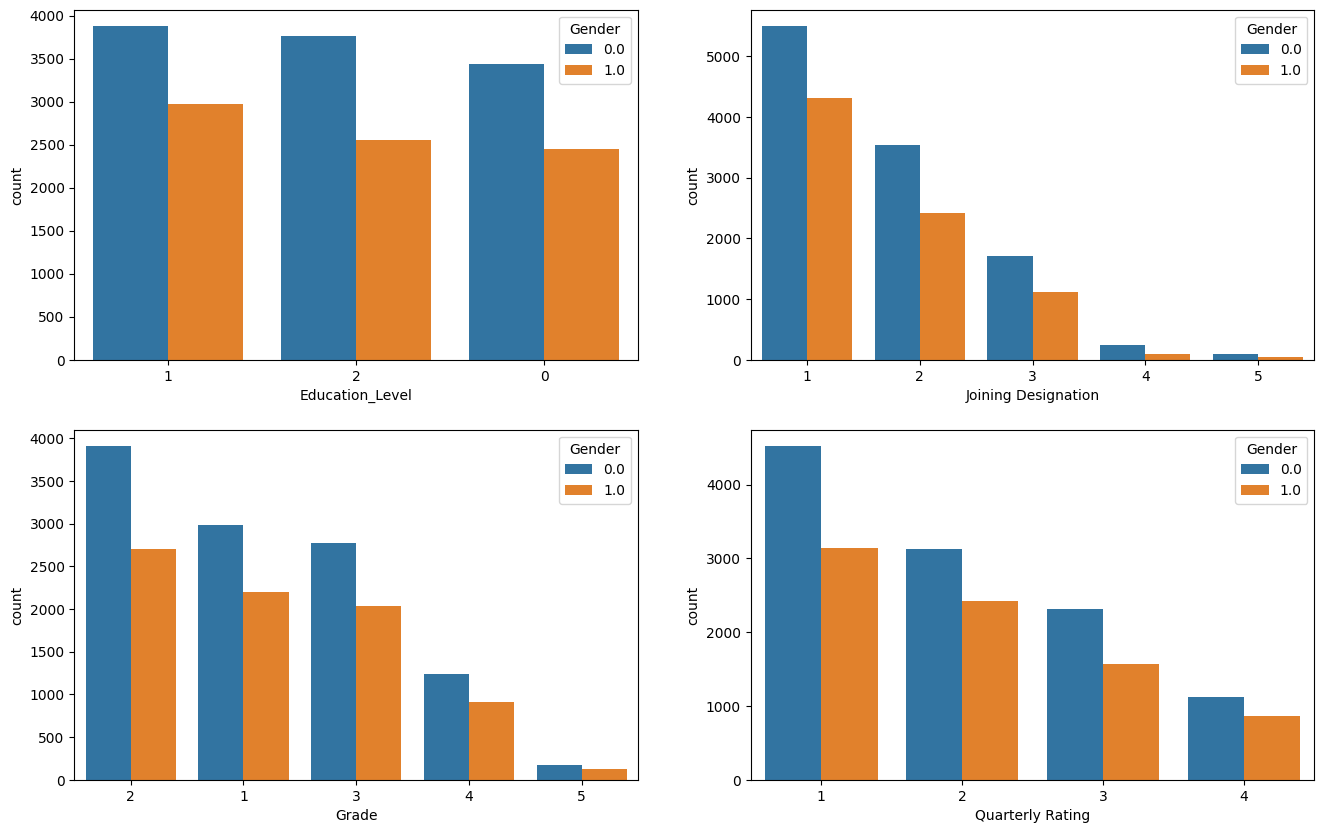

In [ ]:
k=1
for col in col1:
  plt.subplot(2,2,k)
  sns.countplot(data=df,x=col,order=df[col].value_counts().index,hue='Gender')
  k+=1

Education level - Male(0) has higher count compared to female(1) in all education levels

Joining Designation - Male(0) has higher count compared to female(1) in all designations

Grade - Male(0) has higher count compared to female(1) in all Grade levels

Quarterly Rating - Male(0) has higher compared to female(1) in all Quarterly Rating levels

Barplot

# Income barplot

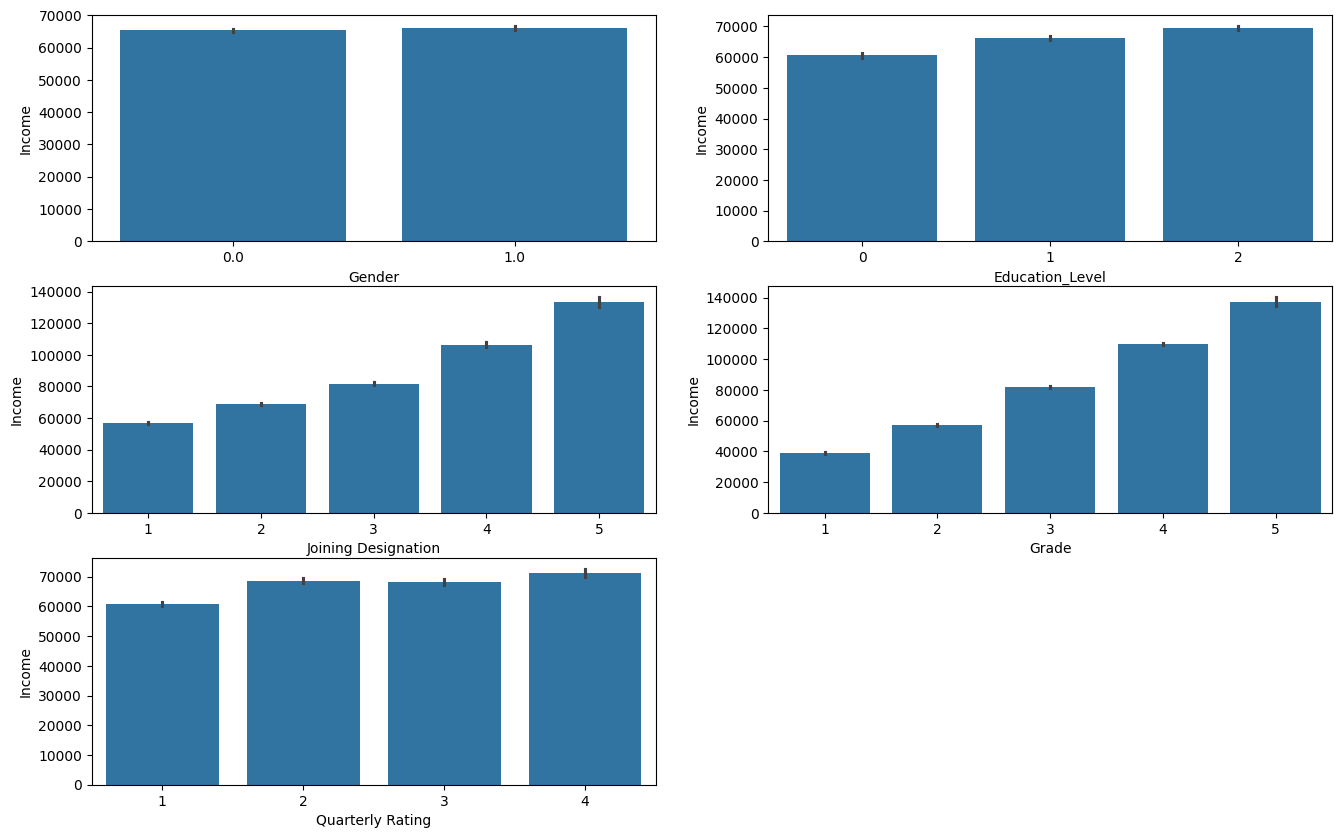

In [ ]:
col1=['Gender','Education_Level', 'Joining Designation', 'Grade', 'Quarterly Rating']
k=1
for col in col1:
  plt.subplot(3,2,k)
  sns.barplot(data=df,x=col,y='Income',estimator='mean')
  k+=1

Income vs Gender - Average income for Gender 0 and 1 are similar

Income vs Education Level - Graduates average income  is higher then followed by 12+ and 10+ education

Income vs Joining Designation - Designation 5 has higher average income compared to others

Income vs Grade - Grade 5 has higher average income compared to others

Income vs Quarterly Rating - Quarterly Rating 4 has higher average income

Total business barplot

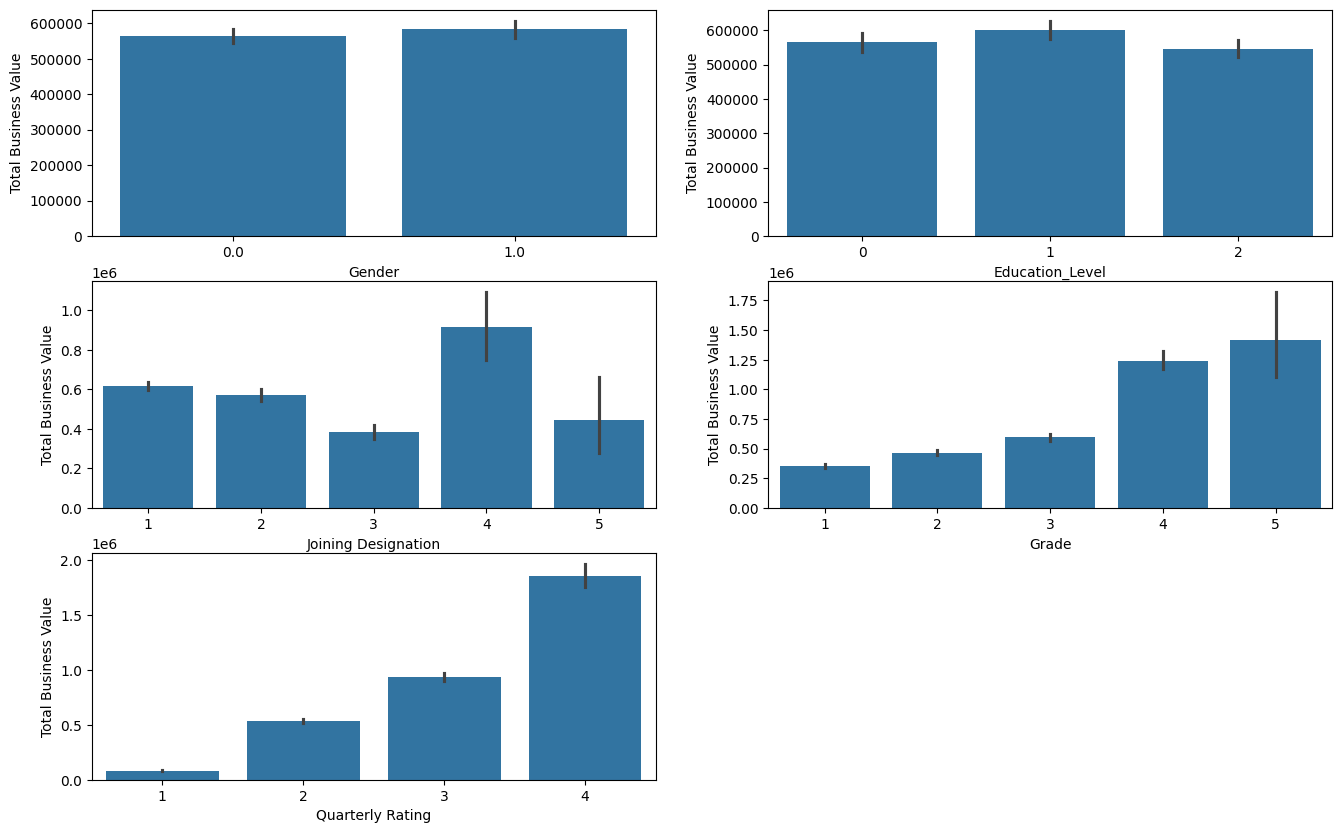

In [ ]:
k=1
for col in col1:
  plt.subplot(3,2,k)
  sns.barplot(data=df,x=col,y='Total Business Value',estimator='mean')
  k+=1

Total business value vs Gender - Average Total business value for Gender female 1 is higher comapred to male 0

Total business value vs Education Level - 12+ average Total business value  is higher then followed by 10+ and graduates education

Total business value vs Joining Designation - Designation 4 has higher average Total business value compared to others

Total business value vs Grade - Grade 5 has higher average Total business value compared to others

Total business value vs Quarterly Rating - Quarterly Rating  4 has higher average Total business value

Boxplot

# income boxplot

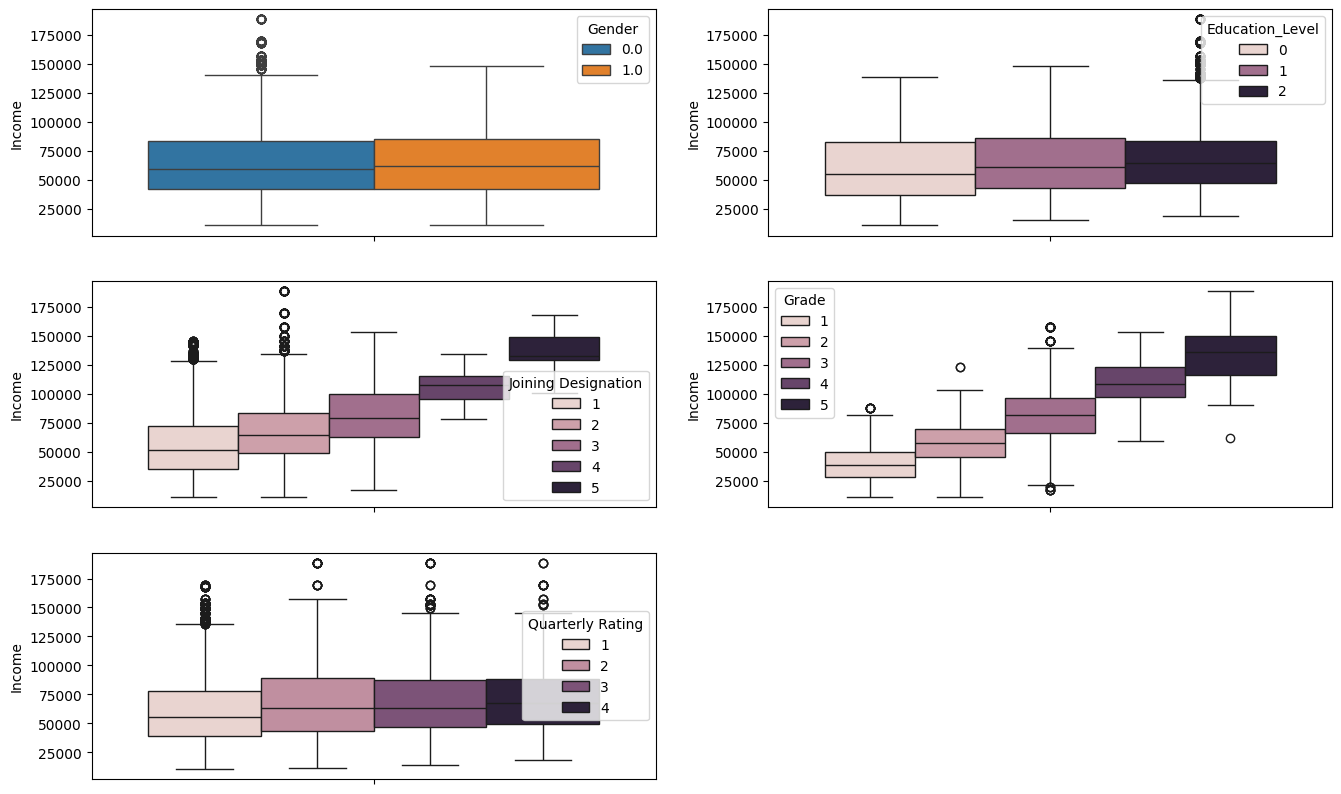

In [ ]:
k=1
for col in col1:
  plt.subplot(3,2,k)
  sns.boxplot(data=df,y='Income',hue=col)
  k+=1

Income vs Gender - outliers are present for male 0

Income vs Education Level - outliers are present for education level 2

Income vs Joining Designation - outliers are present for joining designation 1 and 2

Income vs Grade - outliers are present for Grdae 1,2 and 3

Income vs Quarterly Rating - outliers are present for all Quarterly Rating

#Total business value boxplot

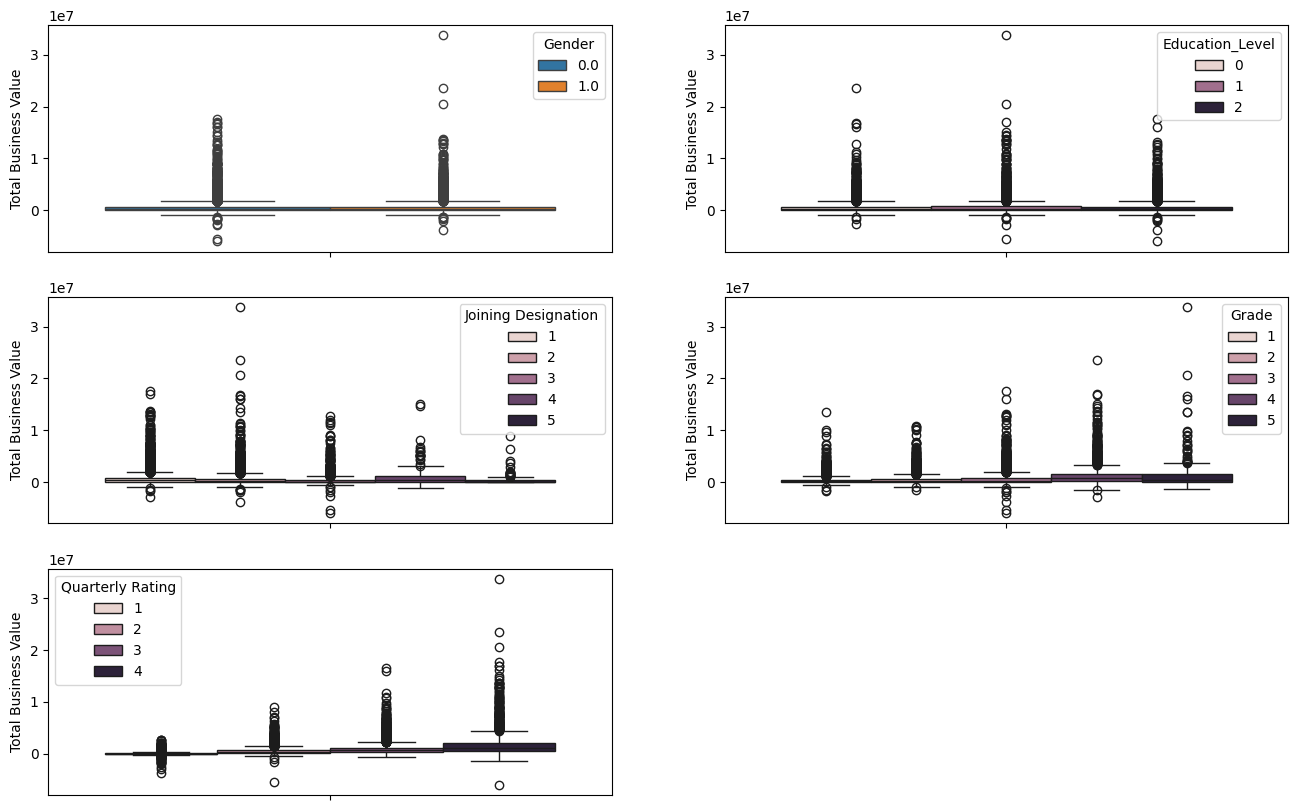

In [ ]:
k=1
for col in col1:
  plt.subplot(3,2,k)
  sns.boxplot(data=df,y='Total Business Value',hue=col)
  k+=1


outliers are present for all

Scatter plot

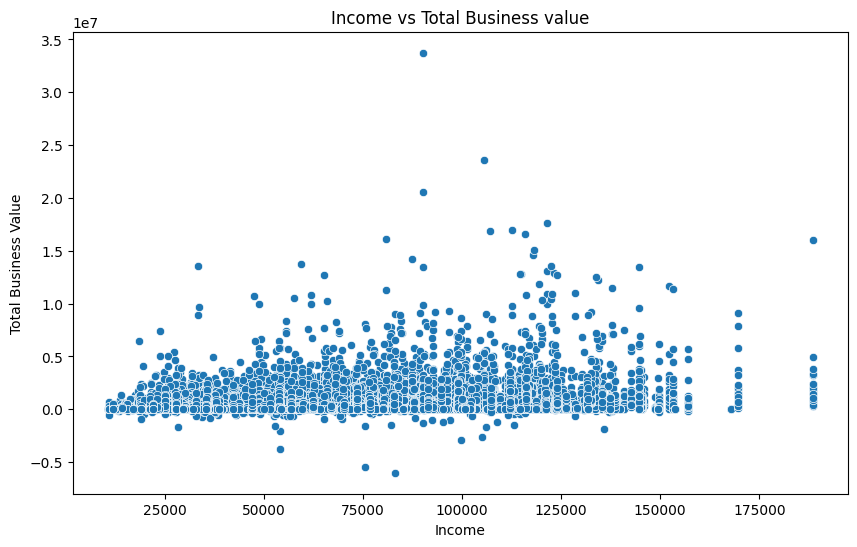

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,y='Total Business Value',x='Income')
plt.title('Income vs Total Business value')
plt.show()

Non linear relationship between features

Multivariate analysis

Barplot

In [ ]:
col1=[
 'Education_Level',
 'Joining Designation',
 'Grade',
 'Quarterly Rating']

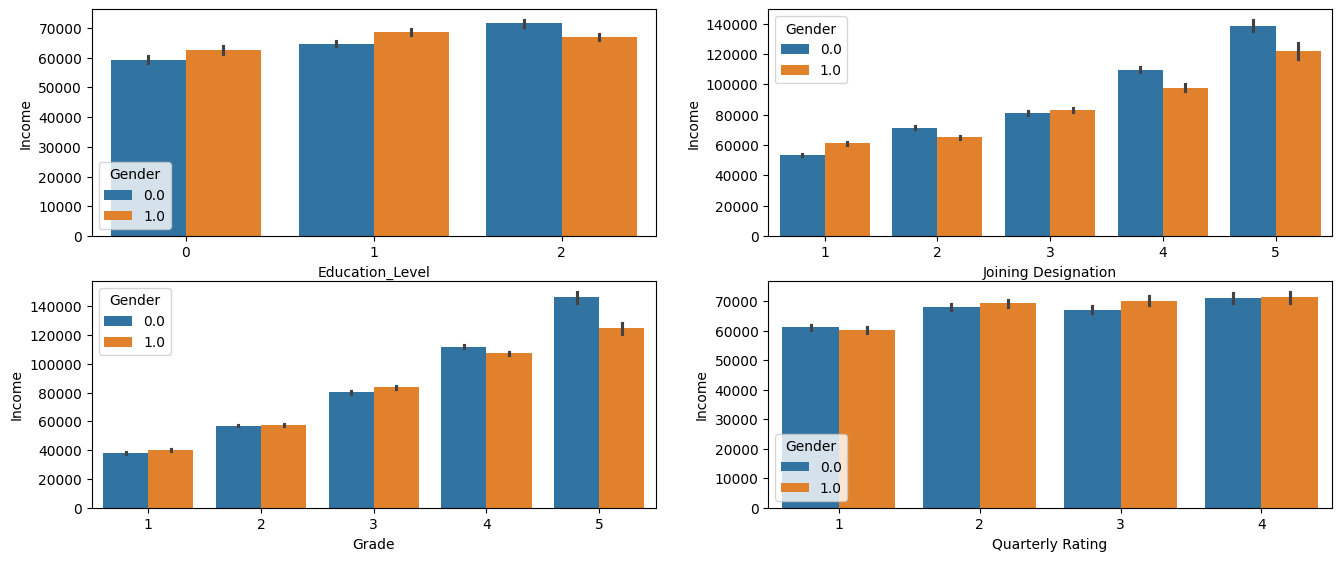

In [ ]:
k=1
for col in col1:
  plt.subplot(3,2,k)
  sns.barplot(data=df,x=col,y='Income',hue='Gender',estimator='mean')
  k+=1

Income vs Education level - Educational level with 2 has highest income compared to others wrt to male (0) is high compared to female(1)

Income vs Joining Designation - Joining designation with 5 has highest income compared to others wrt to male (0) is high compared to female(1)

Income vs Grade - Grade with 5 has highest income compared to others wrt to male (0) is high compared to female(1)

Income vs Quarterly Rating - Quarterly with 4 has highest income comapred to others wrt to female (1) is high compared to male(0)

scatterplot

In [ ]:
col1=['Gender',
 'Education_Level',
 'Joining Designation',
 'Grade',
 'Quarterly Rating']

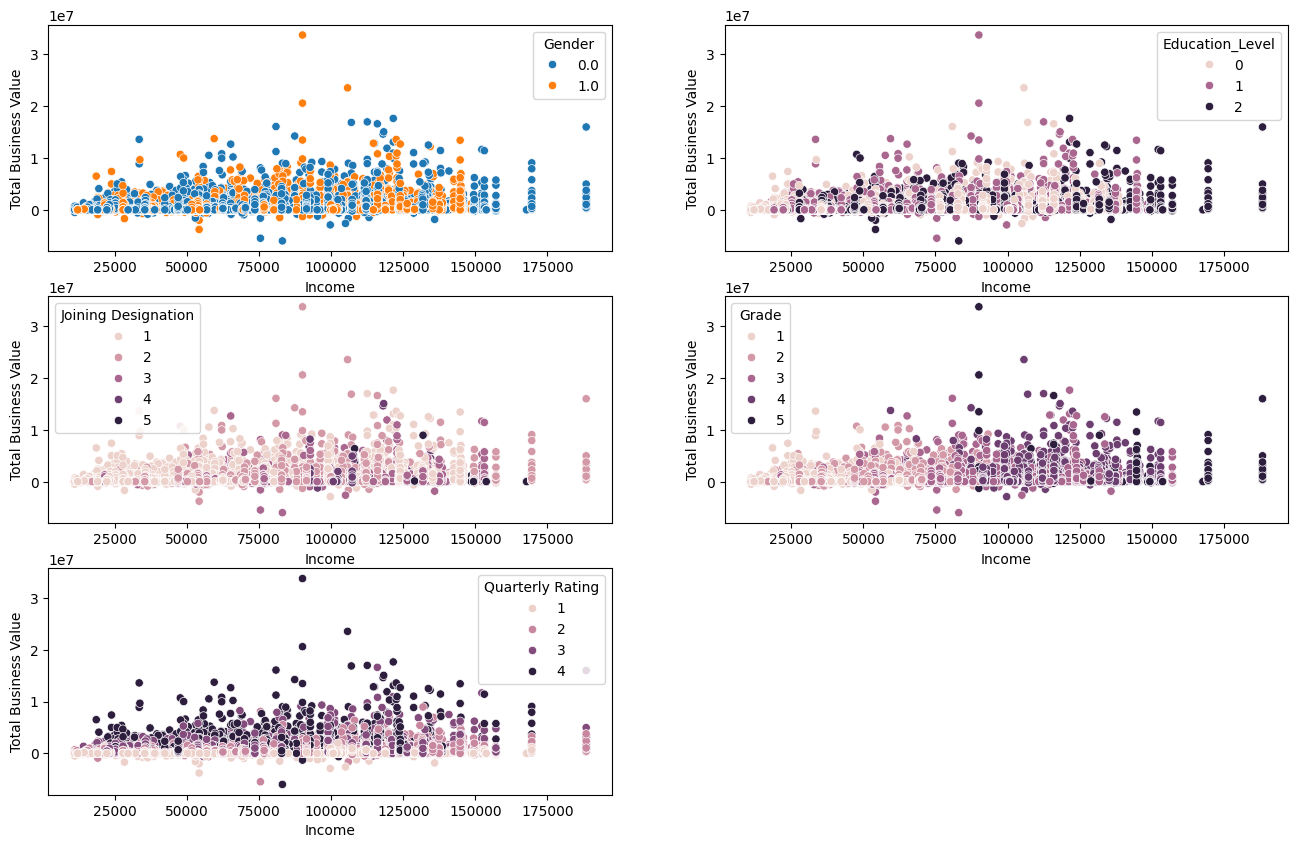

In [ ]:
 k=1
 for col in col1:
  plt.subplot(3,2,k)
  sns.scatterplot(data=df,x='Income',y='Total Business Value',hue=col)
  k+=1

There is no linear relationship between features wrt to gender

#Data Preprocessing

Check for missing values and Prepare data for KNN Imputation

KNN Imputation: KNN imputation is a missing value imputation technique by using KNN algorithm to fill the missing value

Working of KNN Imputation:

For Categorical:

1. Compute the distance between missing row value and every row using euclidean or manhattan distance
2. select the top k nearest neighbors
3. Take the majority/mode of top k neighbors

For Numerical:

1. Compute the distance between missing row value and every row using euclidean or manhattan distance
2. select the top k nearest neighbors
3. Take the mean or median of top k neighbors

In KNN
During training time the data is stored
Every thing happens at the time of testing

In [ ]:
df2=df.copy()

In [ ]:
df2.head()

,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,2019-01-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,2381060,2
1,2019-02-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,-665480,2
2,2019-03-01,1,28.0,0.0,C23,2,57387,2018-12-24,2019-03-11,1,1,0,2
3,2020-11-01,2,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0,1
4,2020-12-01,2,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0,1


Missing values

In [ ]:
df2.isnull().sum()

,0
MMM-YY,0
Driver_ID,0
Age,61
Gender,52
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,17488
Joining Designation,0


The We have driver ID repeated in rows , so KNN imputer on the Gender Binary result would be in 0.2,0.4 so , We can fill the Gender Binary with Ffill (forward fill) and Bfill (Backwardfill)

In [ ]:
df2['Gender']=df2.groupby('Driver_ID')['Gender'].transform(lambda x:x.fillna(method='ffill').fillna(method='bfill'))

In [ ]:
df_imputation=df2.select_dtypes('number')
df_imputation.head()

,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,1,28.0,0.0,2,57387,1,1,2381060,2
1,1,28.0,0.0,2,57387,1,1,-665480,2
2,1,28.0,0.0,2,57387,1,1,0,2
3,2,31.0,0.0,2,67016,2,2,0,1
4,2,31.0,0.0,2,67016,2,2,0,1


Missing values

In [ ]:
#missing value detection
df_imputation.isnull().sum()

,0
Driver_ID,0
Age,61
Gender,0
Education_Level,0
Income,0
Joining Designation,0
Grade,0
Total Business Value,0
Quarterly Rating,0


Age has 61 missing values


In [ ]:
from sklearn.impute import KNNImputer

In [ ]:
impute=KNNImputer(n_neighbors=5,metric='nan_euclidean',weights='uniform')
df3=pd.DataFrame(impute.fit_transform(df_imputation),columns=df_imputation.columns)
df3.head()

,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,1.0,28.0,0.0,2.0,57387.0,1.0,1.0,2381060.0,2.0
1,1.0,28.0,0.0,2.0,57387.0,1.0,1.0,-665480.0,2.0
2,1.0,28.0,0.0,2.0,57387.0,1.0,1.0,0.0,2.0
3,2.0,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0
4,2.0,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0


In [ ]:
#missing value imputation
df3.isnull().sum()

,0
Driver_ID,0
Age,0
Gender,0
Education_Level,0
Income,0
Joining Designation,0
Grade,0
Total Business Value,0
Quarterly Rating,0


In [ ]:
left_vars=set(list(df2.columns)).difference(set(list(df_imputation.columns)))
left_vars=list(left_vars)
left_vars

['City', 'Dateofjoining', 'MMM-YY', 'LastWorkingDate']

Merge the imputed table to left over variable

In [ ]:
df3=pd.concat((df3,df2[left_vars]),axis=1)

In [ ]:
df3.head()

,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,City,Dateofjoining,MMM-YY,LastWorkingDate
0,1.0,28.0,0.0,2.0,57387.0,1.0,1.0,2381060.0,2.0,C23,2018-12-24,2019-01-01,NaT
1,1.0,28.0,0.0,2.0,57387.0,1.0,1.0,-665480.0,2.0,C23,2018-12-24,2019-02-01,NaT
2,1.0,28.0,0.0,2.0,57387.0,1.0,1.0,0.0,2.0,C23,2018-12-24,2019-03-01,2019-03-11
3,2.0,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0,C7,2020-11-06,2020-11-01,NaT
4,2.0,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0,C7,2020-11-06,2020-12-01,NaT


In [ ]:
df3.isnull().sum()

,0
Driver_ID,0
Age,0
Gender,0
Education_Level,0
Income,0
Joining Designation,0
Grade,0
Total Business Value,0
Quarterly Rating,0
City,0


Aggregate data in order to remove multiple occurrences of same driver data (We did something similar in Delhivery business Case)

You can start from storing unique Driver IDs in an empty dataframe and then bring all the features at same level (Groupby Driver ID)

In [ ]:
#Grouping based on Driver ID
df4=df3.groupby('Driver_ID').agg({
    'Age':'max',
    'Gender':'first',
    'Education_Level':'last',
    'Income':'last',
    'Joining Designation':'last',
    'Grade':'last',
    'Total Business Value':'sum',
    'Quarterly Rating':'last',
    'LastWorkingDate':'last',
    'City':'first',
    'Dateofjoining':'first'
}).reset_index()

In [ ]:
df4.head()

,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,LastWorkingDate,City,Dateofjoining
0,1.0,28.0,0.0,2.0,57387.0,1.0,1.0,1715580.0,2.0,2019-03-11,C23,2018-12-24
1,2.0,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0,NaT,C7,2020-11-06
2,4.0,43.0,0.0,2.0,65603.0,2.0,2.0,350000.0,1.0,2020-04-27,C13,2019-12-07
3,5.0,29.0,0.0,0.0,46368.0,1.0,1.0,120360.0,1.0,2019-03-07,C9,2019-01-09
4,6.0,31.0,1.0,1.0,78728.0,3.0,3.0,1265000.0,2.0,NaT,C11,2020-07-31


In [ ]:
df4.shape

(2381, 12)

Feature Engineering Steps:



Create a column which tells whether the quarterly rating has increased for that driver - for those whose quarterly rating has increased we assign the value 1



In [ ]:
first=df3.groupby('Driver_ID').agg({'Quarterly Rating':'first'})
last=df3.groupby('Driver_ID').agg({'Quarterly Rating':'last'})
qr=(last>first)
qr=qr.reset_index()
qr['Quarterly Rating Increased']=qr['Quarterly Rating'].apply(lambda x:1 if x==True else 0)
qr=qr.drop(columns='Quarterly Rating')
qr.head()

,Driver_ID,Quarterly Rating Increased
0,1.0,0
1,2.0,0
2,4.0,0
3,5.0,0
4,6.0,1


Merge the table with df4 table

In [ ]:
df_final=df4.merge(qr,on='Driver_ID',how='inner')
df_final.head()

,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,LastWorkingDate,City,Dateofjoining,Quarterly Rating Increased
0,1.0,28.0,0.0,2.0,57387.0,1.0,1.0,1715580.0,2.0,2019-03-11,C23,2018-12-24,0
1,2.0,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0,NaT,C7,2020-11-06,0
2,4.0,43.0,0.0,2.0,65603.0,2.0,2.0,350000.0,1.0,2020-04-27,C13,2019-12-07,0
3,5.0,29.0,0.0,0.0,46368.0,1.0,1.0,120360.0,1.0,2019-03-07,C9,2019-01-09,0
4,6.0,31.0,1.0,1.0,78728.0,3.0,3.0,1265000.0,2.0,NaT,C11,2020-07-31,1


In [ ]:
# Value counts
df_final['Quarterly Rating Increased'].value_counts()

,count
Quarterly Rating Increased,
0,2023
1,358


Quarterly rating has increased for - 358 drivers

Quarterly rating has not increased for - 2023 drivers

Target variable creation: Create a column called target which tells whether the driver has left the company- driver whose last working day is present will have the value 1

In [ ]:
qr=df3.groupby('Driver_ID').agg({'LastWorkingDate':'last'}).reset_index()
qr['Target']=qr['LastWorkingDate'].isnull()
qr['Target']=qr['Target'].apply(lambda x:0 if x==True else 1)
qr=qr.drop(columns='LastWorkingDate')
qr.head()

,Driver_ID,Target
0,1.0,1
1,2.0,0
2,4.0,1
3,5.0,1
4,6.0,0


Merge the two tables on Driver ID

In [ ]:
df_final=df_final.merge(qr,on='Driver_ID',how='inner')
df_final.head()

,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,LastWorkingDate,City,Dateofjoining,Quarterly Rating Increased,Target
0,1.0,28.0,0.0,2.0,57387.0,1.0,1.0,1715580.0,2.0,2019-03-11,C23,2018-12-24,0,1
1,2.0,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0,NaT,C7,2020-11-06,0,0
2,4.0,43.0,0.0,2.0,65603.0,2.0,2.0,350000.0,1.0,2020-04-27,C13,2019-12-07,0,1
3,5.0,29.0,0.0,0.0,46368.0,1.0,1.0,120360.0,1.0,2019-03-07,C9,2019-01-09,0,1
4,6.0,31.0,1.0,1.0,78728.0,3.0,3.0,1265000.0,2.0,NaT,C11,2020-07-31,1,0


In [ ]:
#value counts
df_final['Target'].value_counts()

,count
Target,
1,1616
0,765


Target - 1 the drivers left are 1616

Target - 0 the drivers working are 765

Create a column which tells whether the monthly income has increased for that driver - for those whose monthly income has increased we assign the value 1



In [ ]:
first=df3.groupby('Driver_ID').agg({'Income':'first'})
last=df3.groupby('Driver_ID').agg({'Income':'last'})
qr=(last>first).reset_index()
qr['Monthly Income Increased']=qr['Income'].astype(int)
qr=qr.drop(columns='Income')
qr.head()

,Driver_ID,Monthly Income Increased
0,1.0,0
1,2.0,0
2,4.0,0
3,5.0,0
4,6.0,0


Merge the table on Driver ID

In [ ]:
df_final=df_final.merge(qr,on='Driver_ID',how='inner')
df_final.head()

,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,LastWorkingDate,City,Dateofjoining,Quarterly Rating Increased,Target,Monthly Income Increased
0,1.0,28.0,0.0,2.0,57387.0,1.0,1.0,1715580.0,2.0,2019-03-11,C23,2018-12-24,0,1,0
1,2.0,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0,NaT,C7,2020-11-06,0,0,0
2,4.0,43.0,0.0,2.0,65603.0,2.0,2.0,350000.0,1.0,2020-04-27,C13,2019-12-07,0,1,0
3,5.0,29.0,0.0,0.0,46368.0,1.0,1.0,120360.0,1.0,2019-03-07,C9,2019-01-09,0,1,0
4,6.0,31.0,1.0,1.0,78728.0,3.0,3.0,1265000.0,2.0,NaT,C11,2020-07-31,1,0,0


In [ ]:
df_final['Monthly Income Increased'].value_counts()

,count
Monthly Income Increased,
0,2338
1,43


Monthly income increased for 43 Drivers

Monthly income did not increase for 2338 drivers

In [ ]:
df_final=df_final.drop(columns=['Driver_ID','LastWorkingDate','Dateofjoining'])
df_final['Gender']=df_final['Gender'].astype('float').astype('int')
df_final.head()

,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,City,Quarterly Rating Increased,Target,Monthly Income Increased
0,28.0,0,2.0,57387.0,1.0,1.0,1715580.0,2.0,C23,0,1,0
1,31.0,0,2.0,67016.0,2.0,2.0,0.0,1.0,C7,0,0,0
2,43.0,0,2.0,65603.0,2.0,2.0,350000.0,1.0,C13,0,1,0
3,29.0,0,0.0,46368.0,1.0,1.0,120360.0,1.0,C9,0,1,0
4,31.0,1,1.0,78728.0,3.0,3.0,1265000.0,2.0,C11,1,0,0


Statistical summary of the derived dataset



In [ ]:
#statistical summary of dataframe
df_final.describe()

,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,Quarterly Rating Increased,Target,Monthly Income Increased
count,2381.000000,2381.000000,2381.00000,2381.000000,2381.000000,2381.000000,2.381000e+03,2381.000000,2381.000000,2381.000000,2381.000000
mean,33.770181,0.410332,1.00756,59334.157077,1.820244,2.096598,4.586742e+06,1.427971,0.150357,0.678706,0.018060
std,5.932239,0.491997,0.81629,28383.666384,0.841433,0.941522,9.127115e+06,0.809839,0.357496,0.467071,0.133195
min,21.000000,0.000000,0.00000,10747.000000,1.000000,1.000000,-1.385530e+06,1.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,0.00000,39104.000000,1.000000,1.000000,0.000000e+00,1.000000,0.000000,0.000000,0.000000
50%,33.000000,0.000000,1.00000,55315.000000,2.000000,2.000000,8.176800e+05,1.000000,0.000000,1.000000,0.000000
75%,37.000000,1.000000,2.00000,75986.000000,2.000000,3.000000,4.173650e+06,2.000000,0.000000,1.000000,0.000000
max,58.000000,1.000000,2.00000,188418.000000,5.000000,5.000000,9.533106e+07,4.000000,1.000000,1.000000,1.000000


Check correlation among independent variables and how they interact with each other



<Axes: >

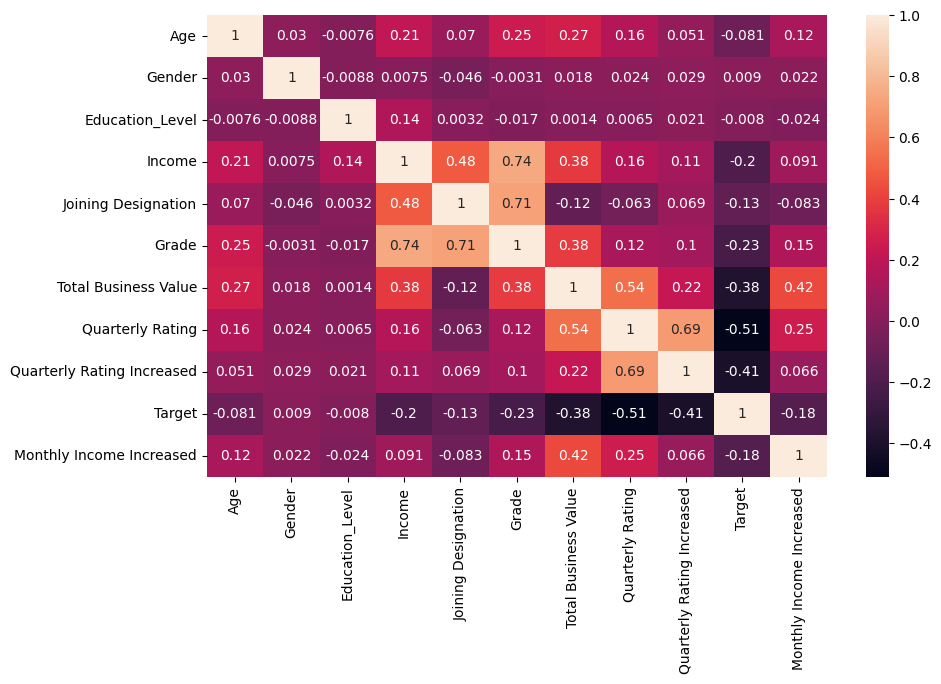

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df_final.select_dtypes(['int','float']).corr(),annot=True)

Grade and income - 0.74 are highly correlated features
Grade and joining designation - 0.71 is highly correlated features
In Decision Tree Algorithm's does'nt get affected by multi collinearity

One hot encoding of the categorical variable

In [ ]:
df_final.head()

,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,City,Quarterly Rating Increased,Target,Monthly Income Increased
0,28.0,0,2.0,57387.0,1.0,1.0,1715580.0,2.0,C23,0,1,0
1,31.0,0,2.0,67016.0,2.0,2.0,0.0,1.0,C7,0,0,0
2,43.0,0,2.0,65603.0,2.0,2.0,350000.0,1.0,C13,0,1,0
3,29.0,0,0.0,46368.0,1.0,1.0,120360.0,1.0,C9,0,1,0
4,31.0,1,1.0,78728.0,3.0,3.0,1265000.0,2.0,C11,1,0,0


In [ ]:
df_final1=df_final.copy()

In [ ]:
df_final1=pd.get_dummies(df_final1,columns=['City'],dtype='int')

In [ ]:
df_final1.head()

,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,Quarterly Rating Increased,Target,...,City_C27,City_C28,City_C29,City_C3,City_C4,City_C5,City_C6,City_C7,City_C8,City_C9
0,28.0,0,2.0,57387.0,1.0,1.0,1715580.0,2.0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,31.0,0,2.0,67016.0,2.0,2.0,0.0,1.0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,43.0,0,2.0,65603.0,2.0,2.0,350000.0,1.0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,29.0,0,0.0,46368.0,1.0,1.0,120360.0,1.0,0,1,...,0,0,0,0,0,0,0,0,0,1
4,31.0,1,1.0,78728.0,3.0,3.0,1265000.0,2.0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_final1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2381 entries, 0 to 2380
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         2381 non-null   float64
 1   Gender                      2381 non-null   int64  
 2   Education_Level             2381 non-null   float64
 3   Income                      2381 non-null   float64
 4   Joining Designation         2381 non-null   float64
 5   Grade                       2381 non-null   float64
 6   Total Business Value        2381 non-null   float64
 7   Quarterly Rating            2381 non-null   float64
 8   Quarterly Rating Increased  2381 non-null   int64  
 9   Target                      2381 non-null   int64  
 10  Monthly Income Increased    2381 non-null   int64  
 11  City_C1                     2381 non-null   int64  
 12  City_C10                    2381 non-null   int64  
 13  City_C11                    2381 

Standardization of training data

Standardization is a technique to where the data is tranformed so that distribution of data has mean=0 and standard deviation=1

z = (x - mean) / standard_deviation


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X=df_final1.drop(columns='Target')
y=df_final1[['Target']]
train_x,test_x,train_y,test_y=train_test_split(X,y,test_size=0.2,random_state=7)

In [ ]:
scaler=StandardScaler()
train_x_scaled=scaler.fit_transform(train_x)
test_x_scaled=scaler.transform(test_x)
train_x_scaled=pd.DataFrame(train_x_scaled,columns=train_x.columns)
test_x_scaled=pd.DataFrame(test_x_scaled,columns=test_x.columns)

In [ ]:
train_x_scaled.head()

,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,Quarterly Rating Increased,Monthly Income Increased,...,City_C27,City_C28,City_C29,City_C3,City_C4,City_C5,City_C6,City_C7,City_C8,City_C9
0,1.413283,-0.843025,-0.015534,-0.035911,1.401488,0.947402,-0.501818,-0.536218,-0.423884,-0.132807,...,-0.198246,-0.183464,4.97290,-0.196810,-0.178825,-0.189496,-0.189496,-0.186501,-0.20109,-0.178825
1,-1.149405,1.186204,1.216825,-1.098189,-0.971507,-1.157445,0.072757,1.918010,2.359135,-0.132807,...,-0.198246,-0.183464,-0.20109,-0.196810,-0.178825,-0.189496,-0.189496,-0.186501,-0.20109,-0.178825
2,1.242437,1.186204,-0.015534,-0.047407,-0.971507,-0.105021,1.263595,1.918010,-0.423884,-0.132807,...,-0.198246,-0.183464,-0.20109,-0.196810,-0.178825,-0.189496,-0.189496,-0.186501,-0.20109,-0.178825
3,-1.149405,-0.843025,-1.247893,0.466998,0.214990,-0.105021,-0.501818,-0.536218,-0.423884,-0.132807,...,-0.198246,-0.183464,-0.20109,-0.196810,-0.178825,-0.189496,-0.189496,-0.186501,-0.20109,-0.178825
4,-0.807713,-0.843025,-1.247893,-0.044946,-0.971507,-1.157445,-0.480760,-0.536218,-0.423884,-0.132807,...,-0.198246,-0.183464,-0.20109,5.081033,-0.178825,-0.189496,-0.189496,-0.186501,-0.20109,-0.178825


In [ ]:
test_x_scaled.head()

,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,Quarterly Rating Increased,Monthly Income Increased,...,City_C27,City_C28,City_C29,City_C3,City_C4,City_C5,City_C6,City_C7,City_C8,City_C9
0,-0.978559,1.186204,-0.015534,-0.636061,-0.971507,-1.157445,-0.362815,-0.536218,-0.423884,-0.132807,...,-0.198246,-0.183464,-0.20109,-0.19681,-0.178825,-0.189496,-0.189496,-0.186501,-0.20109,-0.178825
1,-0.124330,-0.843025,1.216825,-0.228285,-0.971507,-0.105021,1.037942,-0.536218,-0.423884,-0.132807,...,-0.198246,-0.183464,-0.20109,-0.19681,-0.178825,-0.189496,5.277166,-0.186501,-0.20109,-0.178825
2,1.071591,-0.843025,-0.015534,-0.307773,-0.971507,-1.157445,1.008492,0.690896,-0.423884,-0.132807,...,-0.198246,-0.183464,-0.20109,-0.19681,-0.178825,-0.189496,-0.189496,-0.186501,-0.20109,-0.178825
3,-1.832789,-0.843025,-0.015534,-0.904373,-0.971507,-1.157445,-0.501818,-0.536218,-0.423884,-0.132807,...,5.044249,-0.183464,-0.20109,-0.19681,-0.178825,-0.189496,-0.189496,-0.186501,-0.20109,-0.178825
4,0.217362,-0.843025,-1.247893,0.842642,0.214990,-0.105021,-0.501818,-0.536218,-0.423884,-0.132807,...,-0.198246,-0.183464,-0.20109,-0.19681,-0.178825,-0.189496,-0.189496,-0.186501,-0.20109,-0.178825


#Model building

Decision Tree:

Decision Tree is supervised machine learning approach which performs tasks like classification or regression

The feature space is split into smaller regions, that the split is based on input features to create homogenous sub regions with respect to target variable.

At each internal node a decison is made at split and traverse until the leaf node represent predictions

working of Decison Tree

Entropy : measures the impurity or randomness of a node

if entropy is high then node is heterogenous

if entropy is low then node is homogenous

Low entropy->More Homogenous-> Good prediction


Entropy=-summation(probab_i*log(probab_i))


$$
\text{Entropy} = - \sum_{i=1}^{n} p_i \cdot \log_2(p_i)
$$
 where n -> the number of class

 pi -> probaility of each class

 Entropy ranges from [0,1]

Gini Impurity:

Gini impurity measure the impurity at node or measures randomness , it is slightly faster than entropy

if Gini index is low then node is homogenous

if Gini index is high then node is hetrogenous

if Gini index low -> More Homogenous -> Good prediction


Gini index=1-summation(p_i**2)

$$
\text{Gini} = 1 - \sum_{i=1}^{n} p_i^2
$$

where n is the number of classes

p_i is the probablity of classes

Gini index range [0,0.5]

Information Gain:

Information Gain measures the how much entropy is reduced after a split

If Information Gain is high the high reduction in entropy-> More Homogenous -> Good for Prediction

If Information Gain is low then low reduction in entropy-> More Heterogenous -> Not Good for Prediction

For categorical variable:

Compute the IG for all features.

select the features with high IG .

For Numerical variable:

Compute the IG for each posiible threshold of a Numerical features

select the threshold with highest IG



# Information Gain (IG) formula
# IG = Entropy(parent) - ((n1 / n) * Entropy(child1) + (n2 / n) * Entropy(child2))

# Where:
# parent = parent node
# child1, child2 = child nodes after the split
# n = total number of samples in parent node
# n1, n2 = number of samples in child nodes

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
model=DecisionTreeClassifier(max_depth=5,criterion='entropy',class_weight='balanced')
model.fit(train_x_scaled,train_y)
print("Accuracy : ",model.score(train_x_scaled,train_y))
print("Accuracy : ",model.score(test_x_scaled,test_y))

Accuracy :  0.8308823529411765
Accuracy :  0.8113207547169812


Take the best paramenters using Randomized search

In [ ]:
param={
    'max_depth':[3,4,5,6],
    'criterion':['entropy','gini'],
    'class_weight':['balanced','none']
}

In [ ]:
rd=RandomizedSearchCV(estimator=DecisionTreeClassifier(),param_distributions=param,cv=10,n_iter=10,n_jobs=-1,verbose=1)
rd.fit(train_x_scaled,train_y)

Fitting 10 folds for each of 10 candidates, totalling 100 fits


RandomizedSearchCV(cv=10, estimator=DecisionTreeClassifier(), n_jobs=-1,
                   param_distributions={'class_weight': ['balanced', 'none'],
                                        'criterion': ['entropy', 'gini'],
                                        'max_depth': [3, 4, 5, 6]},
                   verbose=1)

In [ ]:
print("Best Score",rd.best_score_)

Best Score 0.7893551942683935


In [ ]:
model=rd.best_estimator_
model

DecisionTreeClassifier(class_weight='balanced', max_depth=3)

In [ ]:
print("Train Accuracy : ",model.score(train_x_scaled,train_y))
print("Test Accuracy  : ",model.score(test_x_scaled,test_y))

Train Accuracy :  0.7967436974789915
Test Accuracy  :  0.7882599580712788


In [ ]:
feature=pd.DataFrame({'Feature_name':train_x_scaled.columns,'weights':model.feature_importances_}).sort_values(by='weights',ascending=False)
feature

,Feature_name,weights
7,Quarterly Rating,0.754712
6,Total Business Value,0.102767
4,Joining Designation,0.101480
8,Quarterly Rating Increased,0.032766
0,Age,0.008274
2,Education_Level,0.000000
1,Gender,0.000000
5,Grade,0.000000
3,Income,0.000000
9,Monthly Income Increased,0.000000


 Ensemble - Bagging Algorithm  

Ensemble learning is a machine learning technique where multiple models are trained and then the predictions are combined to get accurate results

Bagging (Boostraping) is a ensemble learning method where multiple models are trained in parallel by using random sampling of rows and then combining the predictions to get accurate results


1. Random Forest Algorithm :

Random Forest is a type of bagging algorithm where multiple Decision tree models are trained in parallel with Random sampling of rows (bootsraping) and random feature selection an then the predictions of models are combined to provide accurate results

working of Random Forest Algorithm:

Bootstraping : The multiple Decision Tree models are trained by using random sampling of rows and feature selection

Aggregation : Outputs of multiple models are combined ,For classification problem we use mode of predictions , For regression problem we use mean or median of predictions to get the accurate results

Random Forest Reduces the risk of overfitting by:

Bootstraping : Multiple Decsion tree models trained using different random sampling rows and random feature selection it captures different patterns for each row sampling and feature selection  and reduces the risk of overfitting

Aggregation : Outputs of multiple models are combined ,For classification problem we use mode of predictions , For regression problem we use mean or median of predictions to get the accurate results


Random Forest does'nt overfit like Decision Tree

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
model=RandomForestClassifier(n_estimators=100,max_depth=5)
model.fit(train_x_scaled,train_y)
print("Train Accuracy : ",model.score(train_x_scaled,train_y))
print("Test Accuracy  : ",model.score(test_x_scaled,test_y))

Train Accuracy :  0.8261554621848739
Test Accuracy  :  0.8155136268343816


Get the best Parameters using RandomizedSearchCV

In [ ]:
params={
    'n_estimators':[40,50,100,150,200,250],
    'max_depth':[2,3,4],
    'max_samples':[0.4,0.5,0.6,0.8],
    'max_features':[0.4,0.6,0.8],
    'class_weight':['balanced']
}

In [ ]:
rd=RandomizedSearchCV(estimator=RandomForestClassifier(),param_distributions=params,cv=10,n_iter=20,n_jobs=-1,verbose=2)
rd.fit(train_x_scaled,train_y)

Fitting 10 folds for each of 20 candidates, totalling 200 fits


RandomizedSearchCV(cv=10, estimator=RandomForestClassifier(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'class_weight': ['balanced'],
                                        'max_depth': [2, 3, 4],
                                        'max_features': [0.4, 0.6, 0.8],
                                        'max_samples': [0.4, 0.5, 0.6, 0.8],
                                        'n_estimators': [40, 50, 100, 150, 200,
                                                         250]},
                   verbose=2)

In [ ]:
print("Best params : ",rd.best_params_)
print(" Best Score : ",rd.best_score_)

Best params :  {'n_estimators': 200, 'max_samples': 0.4, 'max_features': 0.8, 'max_depth': 4, 'class_weight': 'balanced'}
 Best Score :  0.8003802700468448


In [ ]:
random_model=rd.best_estimator_
random_model

RandomForestClassifier(class_weight='balanced', max_depth=4, max_features=0.8,
                       max_samples=0.4, n_estimators=200)

In [ ]:
print("Train Accuracy : ",random_model.score(train_x_scaled,train_y))
print("Test Accuracy  : ",random_model.score(test_x_scaled,test_y))

Train Accuracy :  0.8146008403361344
Test Accuracy  :  0.7945492662473794


Feature Importance

In [ ]:
Feature_imp=pd.DataFrame({'Features':train_x_scaled.columns,'weights':random_model.feature_importances_}).sort_values(by='weights',ascending=False)
Feature_imp

,Features,weights
7,Quarterly Rating,0.521104
6,Total Business Value,0.186520
4,Joining Designation,0.088397
8,Quarterly Rating Increased,0.055893
3,Income,0.046450
0,Age,0.036542
5,Grade,0.012106
2,Education_Level,0.005931
24,City_C22,0.003161
21,City_C2,0.003071


Random Forest Algorithm reduced overfitting compared to Decision Tree

Random Forest generalizes the data with margin of only small gap

Ensemble : Ensemble learning is a machine learning technique where multiple models are trained and then predictions are combines to get accurate results

Boosting : Boosting is a type of ensemble learning where multiple models (base learners) are trained in sequential order to reduce the error made by previous model and give accurate results

Types of Boosting
 1. GradientBoosting

 2. XGBoost

 3. LightGBM


GradientBoosting : GradientBoosting is a type of ensemble learning where multiple base learners are trained in a sequential order so that the errors made by previous model is fit into next model to reduce the errors and give the accurate results

Each model is called a Base learner

Intial base learner is a mean model with higher bias or error

The errors made by previous base learner is fit into next base learner to reduce the error

The next base learner learns from the erros made by previous base learner

#  Gradient Boosting - Working Steps

### **1. Initialize the model with a constant value**
$$
F_0 = \frac{1}{n} \sum_{i=1}^{n} y_i
$$
This is the initial prediction (mean of target values for regression).

---

### **2. For each model (m = 1, 2, ..., M):**

#### a. Compute residuals (errors) for each data point:
$$
r_{im} = y_i - F_{m-1}(x_i)
$$
Where:  
- *i* → each data point  
- *m* → model iteration  

---

#### b. Train a weak learner (e.g., Decision Tree) on input features **X** and residuals **r<sub>im</sub>**.

---

#### c. Compute the optimal leaf output (γ) for each terminal region (split) **j**:
$$
\gamma_{jm} = \frac{1}{n_j} \sum_{x_i \in R_{jm}} r_{im}
$$
Where *R<sub>jm</sub>* is the region (leaf) **j** of model **m**.

---

#### d. Update the model:
$$
F_m(x) = F_{m-1}(x) + \text{learning\_rate} \times \sum_{j} \gamma_{jm} \cdot I(x \in R_{jm})
$$
Where *I(·)* is an indicator function.

---

### **3. Final Model Output**
$$
F_M(x) = F_0 + \sum_{m=1}^{M} \text{learning\_rate} \times h_m(x)
$$

---


- **Learning rate controls how much each new model contributes → helps reduce overfitting.  



#  Working of Gradient Boosting Classifier

1. **Initialize the first base learner (Decision Tree)** which gives output in logits (raw score):

$$
y_{\text{logit}} = \log\!\left(\frac{p}{1 - p}\right)
$$

Convert the logits score to probabilities using the sigmoid function:

$$
y_{\text{prediction}} = \sigma(y_{\text{logit}}) = \frac{1}{1 + e^{-y_{\text{logit}}}}
$$

---

2. **For each model** \(m = 1, 2, \dots, M\):

**a.** Compute the residuals (pseudo-residuals):

$$
r_{i m} = y_i - y_{\text{prediction}, i}
$$

where \(i\) indexes each data point.

**b.** Train a Decision Tree on input features \(X\) with targets equal to the residuals \(r_{i m}\).  
The tree produces outputs in logit (raw score) form.

---

3. **Update the ensemble model**:

If the tree outputs logits \(y_{\text{logit}}^{(m)}(x)\) for instance \(x\), update:

$$
F_m(x) = F_{m-1}(x) + \text{learning_rate} \times y_{\text{logit}}^{(m)}(x)
$$

Convert the updated logits to probabilities:

$$
y_{\text{prediction}} = \sigma(F_m(x)) = \frac{1}{1 + e^{-F_m(x)}}
$$

---

The **learning rate** controls how much each base learner contributes; smaller values typically improve generalization and reduce overfitting.


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
model=GradientBoostingClassifier(n_estimators=50,max_depth=5,learning_rate=0.1)
model.fit(train_x_scaled,train_y)
print("Train Accuracy : ",model.score(train_x_scaled,train_y))
print("Test Accuracy : ",model.score(test_x_scaled,test_y))

Train Accuracy :  0.8813025210084033
Test Accuracy :  0.8092243186582809


There is overfitting (low bias and high variance)

Train data is able generalize but test data is not able to generalize

Choose best paramters using Randomized search CV

In [ ]:
param={
    'n_estimators':[20,25,30],
    'max_depth':[3,4],
    'learning_rate':[0.01,0.05]
}

In [ ]:
rd=RandomizedSearchCV(estimator=GradientBoostingClassifier(),param_distributions=param,cv=10,n_iter=25,n_jobs=-1,verbose=2)
rd.fit(train_x_scaled,train_y)

Fitting 10 folds for each of 12 candidates, totalling 120 fits


RandomizedSearchCV(cv=10, estimator=GradientBoostingClassifier(), n_iter=25,
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05],
                                        'max_depth': [3, 4],
                                        'n_estimators': [20, 25, 30]},
                   verbose=2)

In [ ]:
print("Best Parameters : ",rd.best_params_)
print("Best Score : ",rd.best_score_)

Best Parameters :  {'n_estimators': 20, 'max_depth': 4, 'learning_rate': 0.05}
Best Score :  0.8088040782584734


In [ ]:
Gradient_model=rd.best_estimator_
Gradient_model
print("Train Accuracy : ",Gradient_model.score(train_x_scaled,train_y))
print("Test Accuracy  : ",Gradient_model.score(test_x_scaled,test_y))

Train Accuracy :  0.8345588235294118
Test Accuracy  :  0.8155136268343816


Train data and Test data has been generalized perfectly in GradientBoostingAlgorithm

Feature importance

In [ ]:
Feature_imp=pd.DataFrame({'Features':train_x_scaled.columns,'weights':Gradient_model.feature_importances_}).sort_values(by='weights',ascending=False)
Feature_imp

,Features,weights
7,Quarterly Rating,6.320287e-01
6,Total Business Value,1.694504e-01
4,Joining Designation,9.274080e-02
3,Income,3.744647e-02
0,Age,2.626714e-02
8,Quarterly Rating Increased,2.621948e-02
5,Grade,5.491041e-03
24,City_C22,2.086830e-03
20,City_C19,1.927450e-03
27,City_C25,1.709505e-03


#XGBoost

XGBoost : Extreme Gradient Boosting means faster and optimized form

working of XGBoost:

1. Parallelization of feature selection:
   
   Compute the Information Gain for all feature parallely and then select the feature with highest Information Gain at single tree node

   It is fast and effecient

2. Parallelization of Building Tree:
   
   Buliding the subtree parallely as there is no influence of subtrees on each other at single tree level

   It is effecient

3. Optimization of Numerical value feature selection:

   Bin the continous value to discrete bins

   compute the Information gain for Bin threshold instead of all continous value

   select the bin threshold with higher information gain

   It is faster and less space memory allocation



In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
model=XGBClassifier(objective='multi:softmax',num_class=2,n_estimators=100,max_depth=5,learning_rate=0.1)
model.fit(train_x_scaled,train_y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_class=2, ...)

In [ ]:
print("Train Accuracy : ",model.score(train_x_scaled,train_y))
print("Test Accuracy  : ",model.score(test_x_scaled,test_y))

Train Accuracy :  0.8907563025210085
Test Accuracy  :  0.8050314465408805


Get Best Parameters using RandomizedSearchCV

In [ ]:
param={
    'objective':['multi:softmax'],
    'num_class':[2],
    'n_estimators':[20,50,100,150,200],
    'max_depth':[2,3],
    'learning_rate':[0.001,0.01]
}

In [ ]:
rd=RandomizedSearchCV(estimator=XGBClassifier(),param_distributions=param,cv=10,n_iter=25,n_jobs=-1,verbose=2)
rd.fit(train_x_scaled,train_y)

Fitting 10 folds for each of 20 candidates, totalling 200 fits


RandomizedSearchCV(cv=10,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrai...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'learning_rate': [0.001, 0.01],
                                        'max_depth': [2, 3],
                                        'n_estimators': [20, 50, 100, 150, 200],
                                        'num_class': [2],
                                        'objective': ['multi:softmax']},
                   verbose=2)

In [ ]:
print("Best Parameter : ",rd.best_params_)
print("Best Score : ",rd.best_score_)

Best Parameter :  {'objective': 'multi:softmax', 'num_class': 2, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01}
Best Score :  0.8077431799393773


In [ ]:
XGB_model=rd.best_estimator_
XGB_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_class=2, ...)

In [ ]:
print("Train Accuracy : ",XGB_model.score(train_x_scaled,train_y))
print("Test Accuracy  : ",XGB_model.score(test_x_scaled,test_y))

Train Accuracy :  0.8251050420168067
Test Accuracy  :  0.8176100628930818


Feature Importance

In [ ]:
Feature_imp=pd.DataFrame({'Features':train_x_scaled.columns,'weights':XGB_model.feature_importances_}).sort_values(by='weights',ascending=False)
Feature_imp

,Features,weights
7,Quarterly Rating,0.587528
8,Quarterly Rating Increased,0.105578
4,Joining Designation,0.093722
6,Total Business Value,0.072587
20,City_C19,0.030190
3,Income,0.027801
0,Age,0.027771
27,City_C25,0.023502
24,City_C22,0.016395
1,Gender,0.014925


#LightGBM

LightGBM is a lighter verison of GradientBoosting Method which is faster and effecient


working of LightGBM:

1. Gradient Based one sided sampling
   
   The multiple Decision tree models are in sequential order

   The Large errors samples from previous base learner is fit to next base learner by random sampling

   The small errors samples that are closer to zero is not fitted to next base leaner by using random sampling

   This helps the model train faster

2. Exclusive Feature Bundling
   
   The number of features are reduced

   The features are combined to bundle when they are mutually exclusive (sparsity) it reduces the dimensionality

   This helps model train faster and effecinet with less space

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
model=LGBMClassifier(objective='binary',n_estimators=100,max_depth=5,learning_rate=0.1)
model.fit(train_x_scaled,train_y)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1287, number of negative: 617
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000773 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 666
[LightGBM] [Info] Number of data points in the train set: 1904, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.675945 -> initscore=0.735200
[LightGBM] [Info] Start training from score 0.735200
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

LGBMClassifier(max_depth=5, objective='binary')

In [ ]:
print("Train Accuracy : ",model.score(train_x_scaled,train_y))
print("Test Accuracy  : ",model.score(test_x_scaled,test_y))

Train Accuracy :  0.8760504201680672
Test Accuracy  :  0.8134171907756813


Best parameters using Randomized search

In [ ]:
param={
    'objective':['binary'],
    'n_estimators':[20,50,100,150,200],
    'max_depth':[3,4,5],
    'learning_rate':[0.001,0.01]
}

In [ ]:
rd=RandomizedSearchCV(estimator=LGBMClassifier(),param_distributions=param,cv=10,n_iter=25,n_jobs=-1,verbose=2)
rd.fit(train_x_scaled,train_y)

Fitting 10 folds for each of 25 candidates, totalling 250 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1287, number of negative: 617
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000810 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 666
[LightGBM] [Info] Number of data points in the train set: 1904, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.675945 -> initscore=0.735200
[LightGBM] [Info] Start training from score 0.735200
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

RandomizedSearchCV(cv=10, estimator=LGBMClassifier(), n_iter=25, n_jobs=-1,
                   param_distributions={'learning_rate': [0.001, 0.01],
                                        'max_depth': [3, 4, 5],
                                        'n_estimators': [20, 50, 100, 150, 200],
                                        'objective': ['binary']},
                   verbose=2)

In [ ]:
print("Best Parameter : ",rd.best_params_)
print("Best Score     : ",rd.best_score_)

Best Parameter :  {'objective': 'binary', 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01}
Best Score     :  0.8077404243593277


In [ ]:
lgbm_model=rd.best_estimator_
lgbm_model

LGBMClassifier(learning_rate=0.01, max_depth=3, n_estimators=200,
               objective='binary')

In [ ]:
print("Train Accuracy : ",lgbm_model.score(train_x_scaled,train_y))
print("Test Accuracy  : ",lgbm_model.score(test_x_scaled,test_y))

Train Accuracy :  0.8177521008403361
Test Accuracy  :  0.8197064989517819


The train Data and test data is able generalize

Feature Importance in LightGBM

In [ ]:
Feature=pd.DataFrame({'Feature':train_x_scaled.columns,'weights':lgbm_model.feature_importances_}).sort_values(by='weights',ascending=False)
Feature

,Feature,weights
6,Total Business Value,511
7,Quarterly Rating,232
4,Joining Designation,228
0,Age,199
3,Income,101
8,Quarterly Rating Increased,62
1,Gender,24
24,City_C22,8
2,Education_Level,0
5,Grade,0


#Results Evaluation

ROC AUC Curve & comments and Classification Report (Confusion Matrix etc)

Roc- Reciever operating characteristic curve

It is a plot between True positive Rate and False negative Rate

If higher the area under the curve then ROC score is good

If lower the area under the curve then ROC score is not good

AUC=1 Good classifier

AUC=0.5 random model

AUC<=0.5 Not a good classifier

True Positive Rate - True positive/(True Positive+False Negative)

False Positive Rate - False Positive/(True Negative+False Positive)

Precision : Out of all predicted class how many are correctly predicted as class 1

Precision=True Positive/(True Positive+False positive)

Recall : out of actual class 1 how many are predicted as class 1

Recall=True Positive/(True Positive+False Negative)

F1 score : F1 score is a harmonic mean of precision and Recall

F1=2*Precision*Recall/(Precision+Recall)

In [ ]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,roc_auc_score,roc_curve

Random Forest Model Result evaluation

In [ ]:
random_model
y_prob=random_model.predict_proba(test_x_scaled)[:,1]
y_prediction=random_model.predict(test_x_scaled)

ROC

ROC AUC Score :  0.8077199539965497


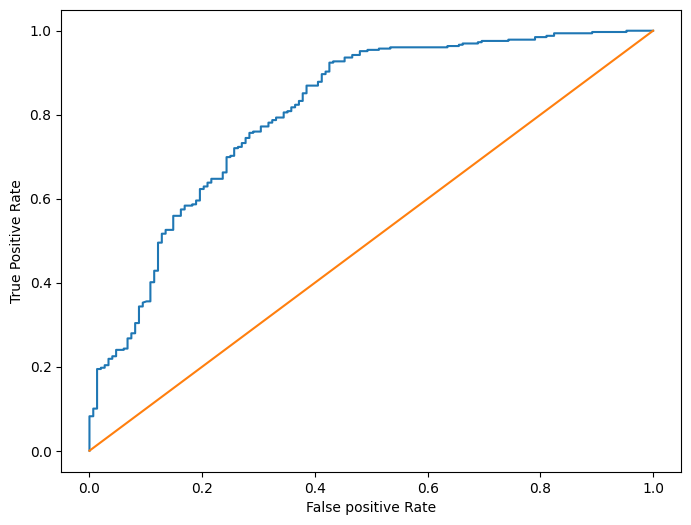

In [ ]:
score=roc_auc_score(test_y,y_prob)
print("ROC AUC Score : ",score)
fpr,tpr,threshold=roc_curve(test_y,y_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr)
plt.plot(fpr,fpr)
plt.xlabel("False positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

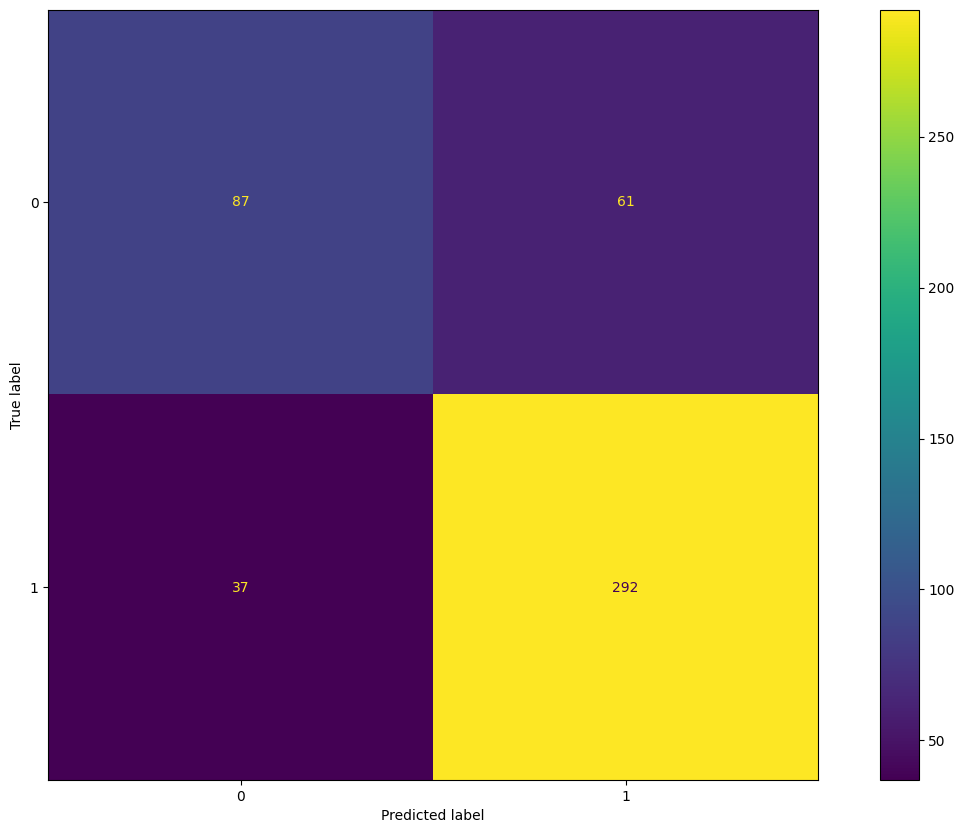

In [ ]:
#confusion matrix

cm=confusion_matrix(test_y,y_prediction)
ConfusionMatrixDisplay(cm).plot()

In [ ]:
#classification_report
print(classification_report(test_y,y_prediction))

              precision    recall  f1-score   support

           0       0.70      0.59      0.64       148
           1       0.83      0.89      0.86       329

    accuracy                           0.79       477
   macro avg       0.76      0.74      0.75       477
weighted avg       0.79      0.79      0.79       477



The problem states about chrun rate of drivers so drivers leaving matters more that is class 1

precision for class 1 is good

recall for class 1 is good

f1-score for class 1 is good

Gradient Boosting Model Result evaluation

In [ ]:
Gradient_model
y_prob=Gradient_model.predict_proba(test_x_scaled)[:,1]
y_prediction=Gradient_model.predict(test_x_scaled)

ROC AUC Score :  0.8139119362523618


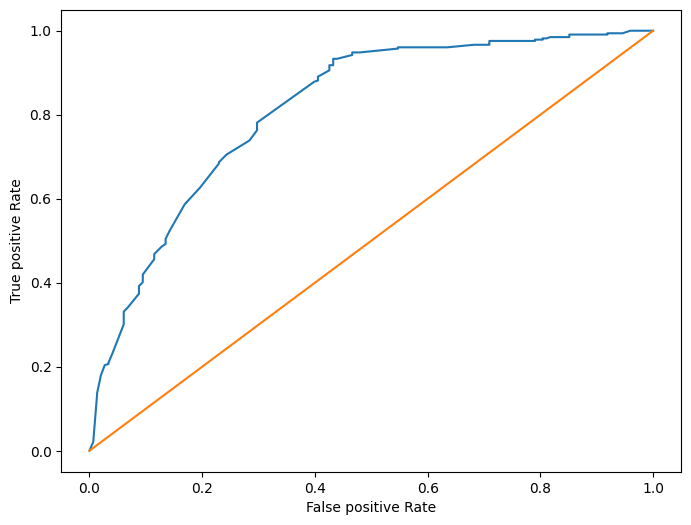

In [ ]:
#ROC AUC

score=roc_auc_score(test_y,y_prob)
print("ROC AUC Score : ",score)
plt.figure(figsize=(8,6))
fpr,tpr,threshold=roc_curve(test_y,y_prob)
plt.plot(fpr,tpr)
plt.plot(fpr,fpr)
plt.xlabel('False positive Rate')
plt.ylabel('True positive Rate')
plt.show()

ROC AUC Score is 0.81 which is very good

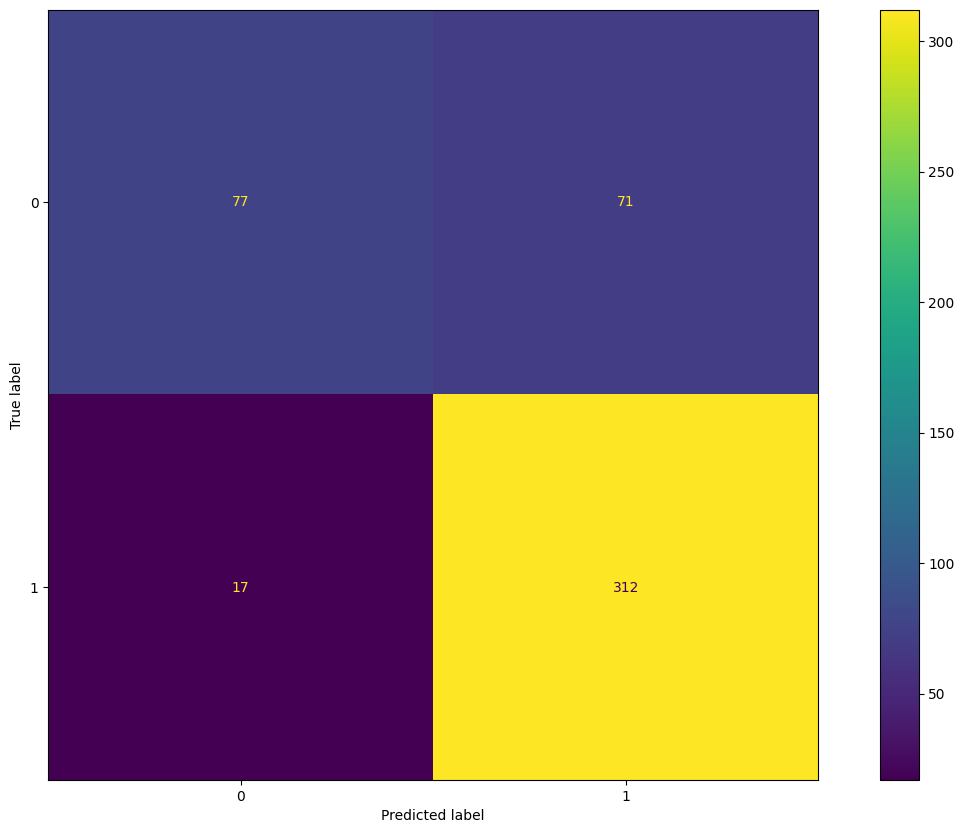

In [ ]:
#confusion matrix
cm=confusion_matrix(test_y,y_prediction)
ConfusionMatrixDisplay(cm).plot()

In [ ]:
#classification report

print(classification_report(test_y,y_prediction))

              precision    recall  f1-score   support

           0       0.82      0.52      0.64       148
           1       0.81      0.95      0.88       329

    accuracy                           0.82       477
   macro avg       0.82      0.73      0.76       477
weighted avg       0.82      0.82      0.80       477



Driver churn rate like the driver leaving (1) are important so

precision for class 1 is 0.81

recall for class 1 is 0.95

f1-score for class 1 is 0.88



XGBoost Model Result evaluation

In [ ]:
XGB_model
y_prob=XGB_model.predict_proba(test_x_scaled)[:,1]
y_prediction=XGB_model.predict(test_x_scaled)

ROC AUC SCORE :  0.8072065226320545


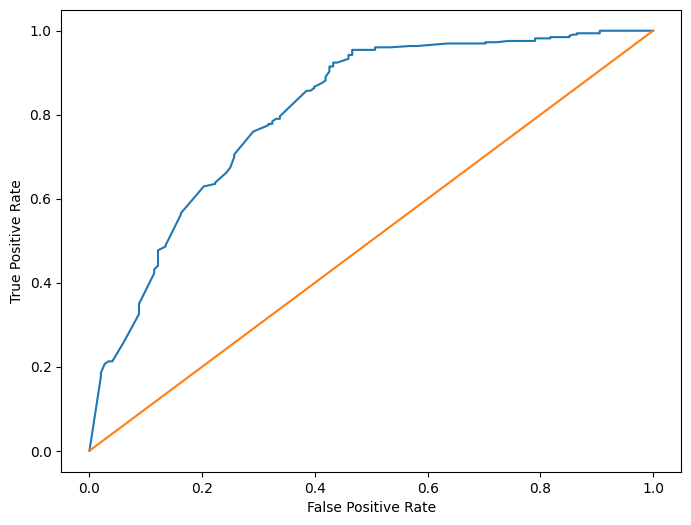

In [ ]:
# ROC_AUC_SCORE

score=roc_auc_score(test_y,y_prob)
print("ROC AUC SCORE : ",score)
plt.figure(figsize=(8,6))
fpr,tpr,threshold=roc_curve(test_y,y_prob)
plt.plot(fpr,tpr)
plt.plot(fpr,fpr)
plt.xlabel("False Positive Rate")
plt.ylabel('True Positive Rate')
plt.show()

ROC AUC score - 0.807 which is good

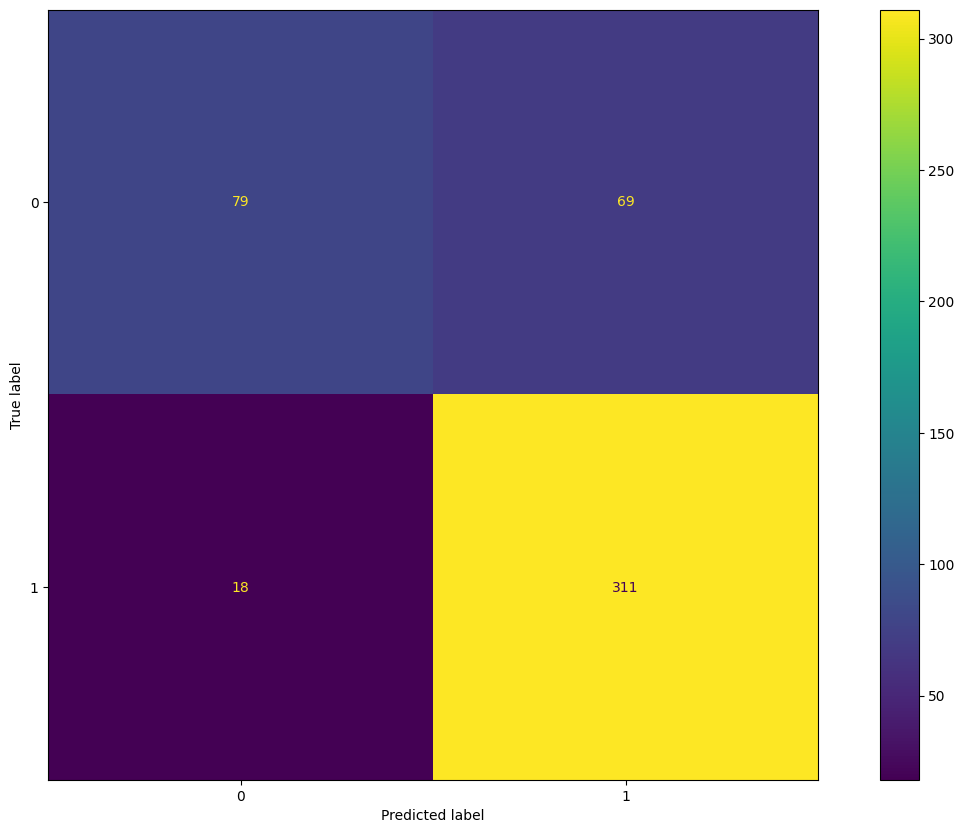

In [ ]:
#confusion matrix
cm=confusion_matrix(test_y,y_prediction)
ConfusionMatrixDisplay(cm).plot()

In [ ]:
# classification_report
print(classification_report(test_y,y_prediction))

              precision    recall  f1-score   support

           0       0.81      0.53      0.64       148
           1       0.82      0.95      0.88       329

    accuracy                           0.82       477
   macro avg       0.82      0.74      0.76       477
weighted avg       0.82      0.82      0.81       477



The chrun rate of driver that is driver leaving class 1 is important

precision for class 1 is 0.82

recall for class 1 is 0.95

f1-score for class 1 is 0.88

LightGBM Model Result Evaluation

In [ ]:
lgbm_model
y_prob=lgbm_model.predict_proba(test_x_scaled)[:,1]
y_prediction=lgbm_model.predict(test_x_scaled)

ROC AUC SCORE :  0.8087365480982502


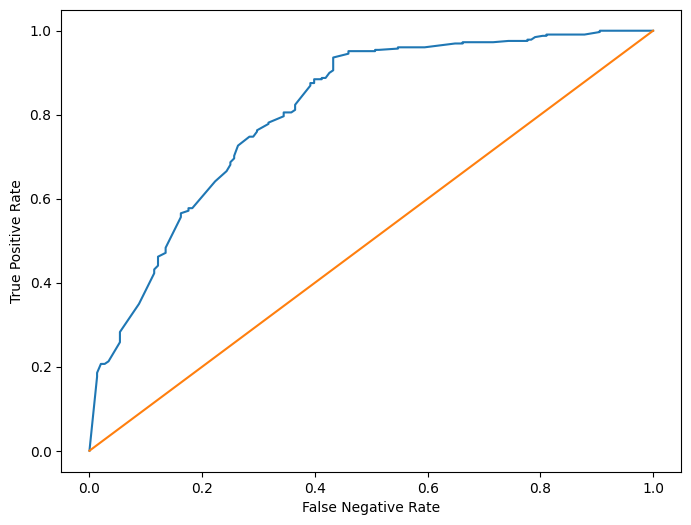

In [ ]:
#ROC_AUC_SCORE

score=roc_auc_score(test_y,y_prob)
print("ROC AUC SCORE : ",score)
fpr,tpr,threshold=roc_curve(test_y,y_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr)
plt.plot(fpr,fpr)
plt.xlabel('False Negative Rate')
plt.ylabel('True Positive Rate')
plt.show()

ROC score is 0.808 is good

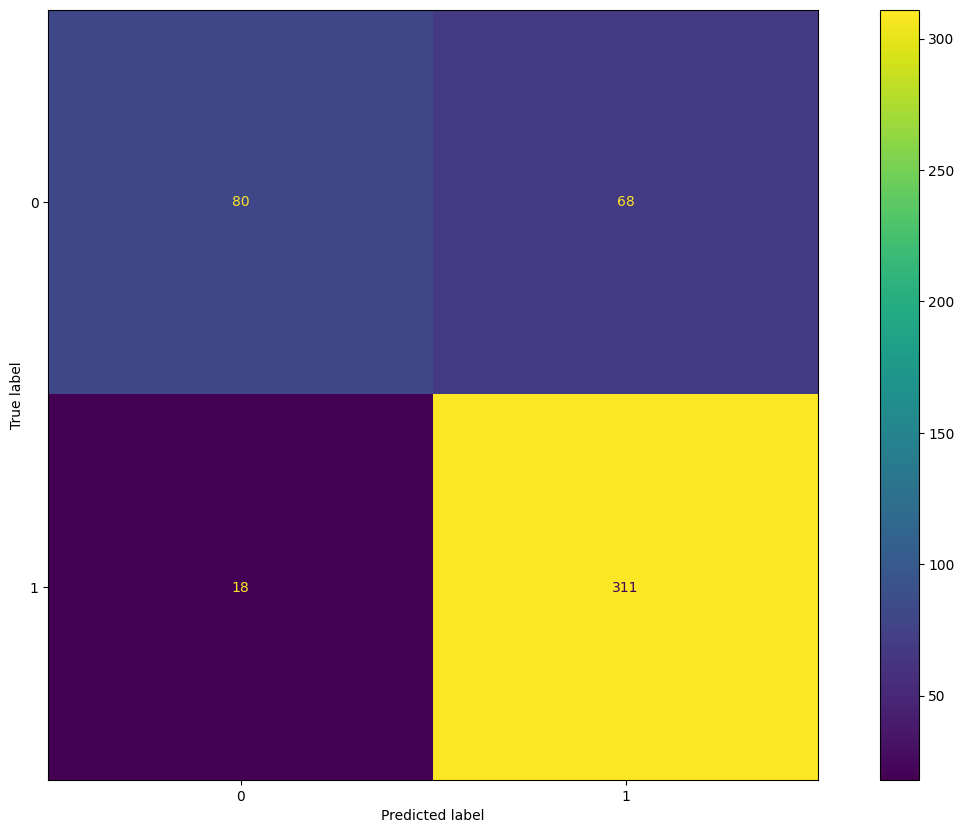

In [ ]:
#confusion matrix
cm=confusion_matrix(test_y,y_prediction)
ConfusionMatrixDisplay(cm).plot()

In [ ]:
#classification_report

print(classification_report(test_y,y_prediction))

              precision    recall  f1-score   support

           0       0.82      0.54      0.65       148
           1       0.82      0.95      0.88       329

    accuracy                           0.82       477
   macro avg       0.82      0.74      0.76       477
weighted avg       0.82      0.82      0.81       477



Class 1 driver leaving the comapny is important do

precision for class 1 is 0.82 is good

recall for class 1 is 0.95 is good

f1-score for class 1 is 0.88 is good

Actionable Insights & Recommendations

In [ ]:
df_final.head()

,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,City,Quarterly Rating Increased,Target,Monthly Income Increased
0,28.0,0,2.0,57387.0,1.0,1.0,1715580.0,2.0,C23,0,1,0
1,31.0,0,2.0,67016.0,2.0,2.0,0.0,1.0,C7,0,0,0
2,43.0,0,2.0,65603.0,2.0,2.0,350000.0,1.0,C13,0,1,0
3,29.0,0,0.0,46368.0,1.0,1.0,120360.0,1.0,C9,0,1,0
4,31.0,1,1.0,78728.0,3.0,3.0,1265000.0,2.0,C11,1,0,0


In [ ]:
len(df_final[(df_final['Quarterly Rating Increased']==0)&(df_final['Target']==1)])

1534

Insights :
  
1. Target -1616 Drivers left the company where as 765 drivers stayed in the company

2. Gender -1404 Drivers are male and 977 drivers are female

3. 948 male drivers and 668 female drivers left the company

4. Quarterly Rating Increased - Quarterly Rating Increased for 2023 drivers and Quarterly Rating has not Increased for 358

5. Monthly Income Increased - Monthly Income Increased for 2338 Drivers and Monthly Income did not increase for 43 Drivers

6. Quarterly Rating Increased , Total Business value , Quartely Rating and joining designation has high feature importance and has high impact on the target variable

7. City has no feature importance

8. 1534 drivers are leaving the company who's Quarterly Rating has not increased ,So company should analysis why customers are not rating the drivers

9. There is not very high recall value for class 0 , it is due to imbalanced dataset so it is due to small dataset

10. XGBoost model has high recall with 95% and high precision with 81% for class 1 that is drivers leaving the company